# Heart Disease Dataset 
(Dataset disponível em > [Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset?resource=download) <)

A principal ideia desse Dataset é de alguma maneira conseguir preditar um indíviduo possivelmente com alguma doença cardíaca a partir de 

fatores pessoiais. 


Esse Dataset reúne dados de 1988 de 4 lugares diferentes, sendo eles: Cleveland, Hungary, Switzerland e Long Beach V. As colunas são compostas por essas 14 variáveis:



1. **Idade**

2. **Sexo**

3. **Tipo_de_dor_no_peito (4 valores possíveis)**

4. **Pressao_arterial_em_repouso**

5. **Colesterol_serico_mg_dl**

6. **Glicemia_de_jejum_maior_120mg_dl**

7. **Eletrocardiograma_repouso (valores: 0, 1, 2)**

8. **Frequencia_cardiaca_maxima**

9. **Angina_induzida_por_exercicio**

10. **Oldpeak (depressão do segmento ST induzida pelo exercício em relação ao repouso)**

11. **Inclinacao_ST_pico_exercicio**

12. **Numero_grandes_vasos_fluorescencia (valores: 0–3)**

13. **Escala_defeito (0 = normal; 1 = defeito fixo; 2 = defeito reversível)**


<span style="color:red">IMPORTANTE</span>

Mesmo que o Dataset apresente referências de coleta para aumentar sua veracidade, **ele** ainda pode **gerar desconfiança**.

Ao entrar na aba <span style="color:#c7c77d">Discussion</span> do Kaggle, nos deparamos com um <i>paper</i> que mostra a inconsistência desse Dataset em relação ao lugar de onde foi coletado: [paper](https://libres.uncg.edu/ir/ecsu/f/Brandon_Simmons_Thesis-Final.pdf). Veja um exemplo de inconsistência na imagem a seguir:

![image](images/paperex.png)

Então provavelmente o Dataset foi modificado para que modelos obtivessem resultados melhores.

Por exemplo:

Foi observado que muitos modelos classificavam errado específicos "x" instâncias não doentes como doentes,

logo foram alterados os seus targets.

Para contornar essa situação iremos "aleatorizar" um pouco nossas instâncias, removendo dados aleatoriamente e depois

fazendo um método de imputação

# Limpeza Inicial do Dataset

In [184]:
# Importações Iniciais

import numpy as np
import pandas as pd

In [185]:
# Carregando Dataset

heart_ds = pd.read_csv("data/heart.csv")
heart_ds.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [186]:
len(heart_ds)

1025

In [187]:
heart_ds.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool

In [188]:
heart_ds = heart_ds.drop_duplicates()
len(heart_ds)

302

Temos inicialmente 1025 pacientes para analisar, porém ao analisarmos mais a fundo vemos que vários desses dados são dados duplicados, ou seja, são apenas linhas repetidas, e elaborar modelos com Datasets com dados repetidos é péssimo, já que dessa maneira estamos enviesando a distribuição dos dados.

# Delete e Imputação de Dados

In [189]:
# Apagando dados aleatórios
base = heart_ds.copy()
fonte = "heart_ds (kernel)"

print(f"Fonte de dados: {fonte} - shape: {base.shape}")

# 2) Definir coluna alvo (não apagaremos o alvo para manter a tarefa de classificação)
if 'target' in base.columns:
    target_col = 'target'

# 3) Copiar e aplicar máscara aleatória de 20% (por célula), exceto na coluna alvo
rng = np.random.default_rng(42)
mask = rng.random(base.shape) < 0.2
if target_col in base.columns:
    target_idx = base.columns.get_loc(target_col)
    mask[:, target_idx] = False

heart_ds_missing = base.copy()
# Aplicar NaN com base na máscara (funciona para numéricos e também converte ints para float quando necessário)
heart_ds_missing = heart_ds_missing.mask(mask)

# 4) Relatório de faltantes por coluna
na_counts = heart_ds_missing.isna().sum()
print("Valores faltantes por coluna (após mascarar 20%):")
print(na_counts.to_string())

# 5) Pré-visualização
display(heart_ds_missing.head())

Fonte de dados: heart_ds (kernel) - shape: (302, 14)
Valores faltantes por coluna (após mascarar 20%):
age         54
sex         65
cp          70
trestbps    62
chol        61
fbs         63
restecg     74
thalach     68
exang       58
oldpeak     56
slope       58
ca          58
thal        59
target       0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,NaN,0.0,1.0,168.0,NaN,1.0,2.0,2.0,3.0,0
1,53.0,1.0,0.0,NaN,203.0,1.0,0.0,155.0,1.0,3.1,0.0,NaN,3.0,0
2,NaN,1.0,0.0,145.0,174.0,0.0,1.0,NaN,NaN,2.6,0.0,0.0,3.0,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,NaN,NaN,NaN,2.0,1.0,3.0,0
4,62.0,0.0,NaN,NaN,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,NaN,0


Vamos passar o Dataframe com os novos valores de <span style="color:yellow">NaN</span> para uma matriz e fazer então a imputação

In [190]:
def npar_to_df(Matrix:np.array) -> pd.DataFrame:
    dict_ = {}
    list_vars = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]
    list_coluns = []
    for i in range(14):
        list_coluns.append(Matrix[i])
    for i in range(14):
        dict_[list_vars[i]] =  list_coluns[i]
    
    return pd.DataFrame(dict_)

    

In [191]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

scaler = StandardScaler()
heart_scaled = scaler.fit_transform(heart_ds_missing)

imputer = KNNImputer(n_neighbors=5)
heart_imputed_scaled = imputer.fit_transform(heart_scaled)

heart_imputed = scaler.inverse_transform(heart_imputed_scaled)

heart_imputed = pd.DataFrame(heart_imputed, columns=heart_ds_missing.columns)

In [192]:
heart_imputed.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,240.8,0.0,1.0,168.0,0.6,1.0,2.0,2.0,3.0,0.0
1,53.0,1.0,0.0,149.6,203.0,1.0,0.0,155.0,1.0,3.1,0.0,1.4,3.0,0.0
2,53.8,1.0,0.0,145.0,174.0,0.0,1.0,142.8,0.2,2.6,0.0,0.0,3.0,0.0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,146.8,0.6,1.8,2.0,1.0,3.0,0.0
4,62.0,0.0,0.4,127.6,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,2.6,0.0


In [193]:
heart_imputed["sex"] = heart_imputed["sex"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["fbs"] = heart_imputed["fbs"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["exang"] = heart_imputed["exang"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["cp"]      = np.clip(np.round(heart_imputed["cp"]), 0, 3)
heart_imputed["restecg"] = np.clip(np.round(heart_imputed["restecg"]), 0, 2)
heart_imputed["slope"]   = np.clip(np.round(heart_imputed["slope"]), 0, 2)
heart_imputed["ca"]      = np.clip(np.round(heart_imputed["ca"]), 0, 4)
heart_imputed["thal"]    = np.clip(np.round(heart_imputed["thal"]), 0, 3)




In [194]:
heart_imputed["cp"]      = np.clip(np.round(heart_imputed["cp"]), 0, 3)
heart_imputed["restecg"] = np.clip(np.round(heart_imputed["restecg"]), 0, 2)
heart_imputed["slope"]   = np.clip(np.round(heart_imputed["slope"]), 0, 2)
heart_imputed["ca"]      = np.clip(np.round(heart_imputed["ca"]), 0, 4)
heart_imputed["thal"]    = np.clip(np.round(heart_imputed["thal"]), 0, 3)


# Análise Exploratória

In [195]:
# Informações
heart_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    float64
 1   sex       302 non-null    int64  
 2   cp        302 non-null    float64
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    float64
 7   thalach   302 non-null    float64
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    float64
 11  ca        302 non-null    float64
 12  thal      302 non-null    float64
 13  target    302 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 33.2 KB


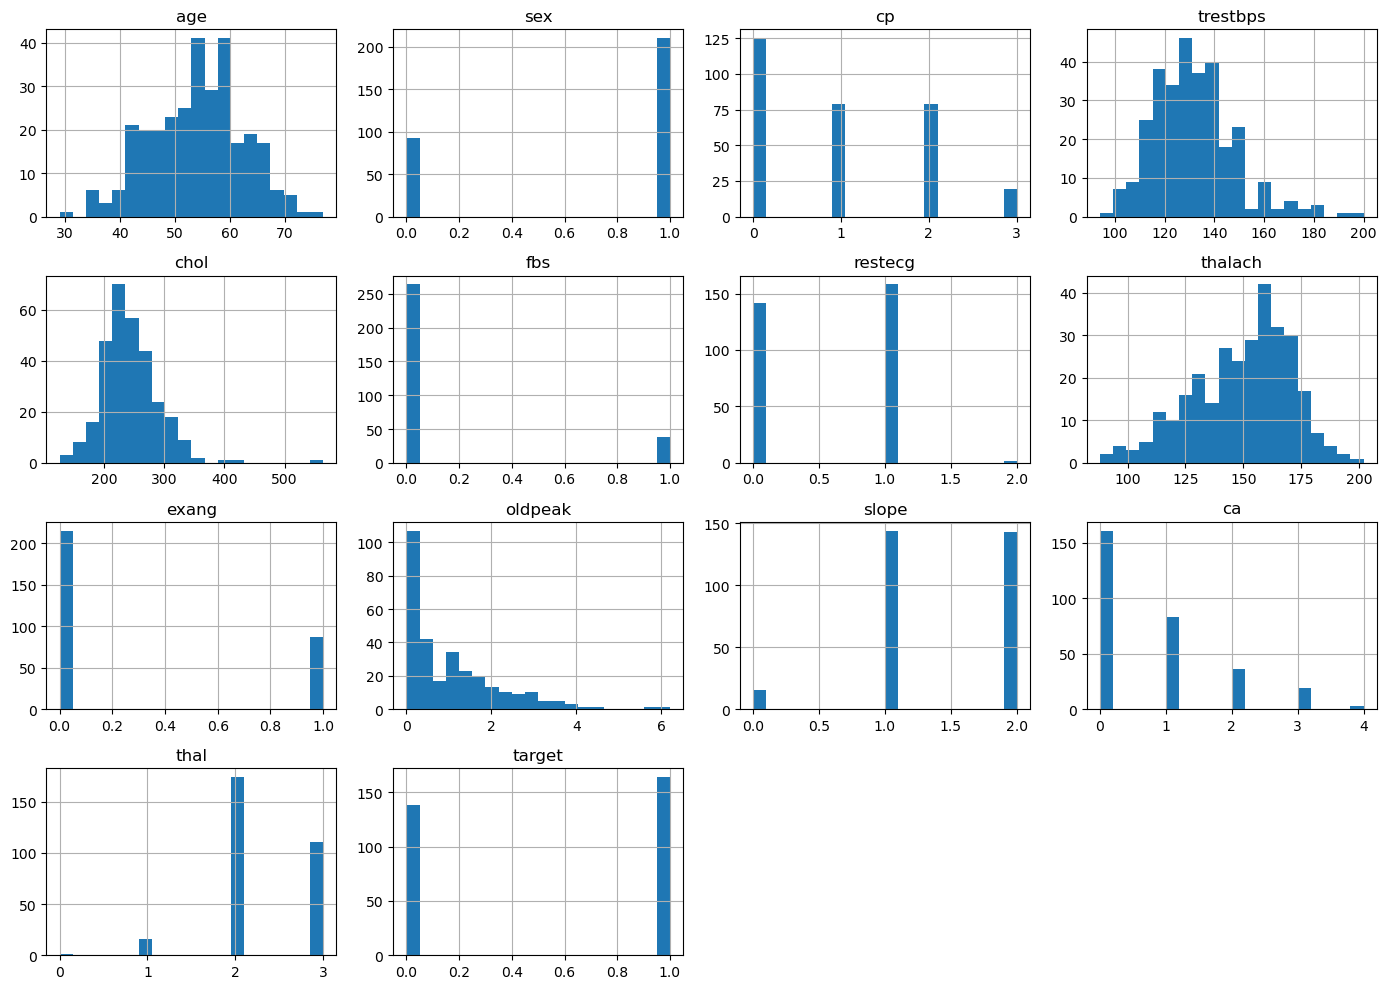

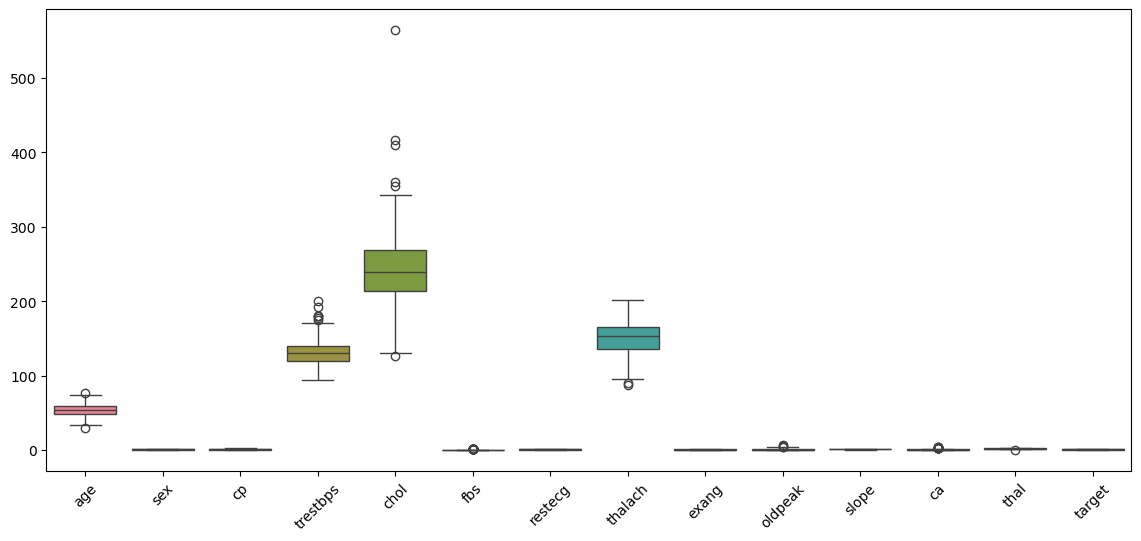

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

heart_imputed.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Boxplots para verificar outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=heart_imputed.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()
     


Podemos claramente ver um outlier olhando para a coluna **chol** então retiraremos ele para não afetar os nossos resultados

In [197]:
heart_imputed = heart_imputed.reset_index()
heart_imputed.loc[heart_imputed["chol"] > 500]

,index,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
128,128,67.0,0,2.0,115.0,564.0,0,0.0,160.0,0,1.6,2.0,0.0,3.0,1.0


In [198]:
heart_imputed = heart_imputed.drop(index = 128)

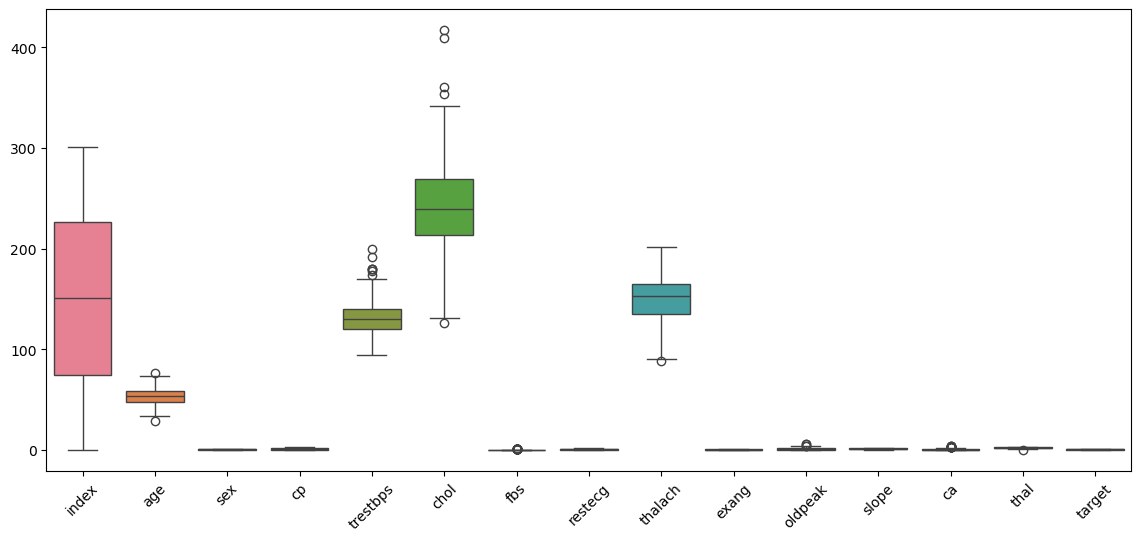

In [199]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=heart_imputed.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()

A distância entre pontos em uma reta é apenas dada por $p_2 - p_1$

porém quanto mais aumentamos a dimensão mesmo que a diferença nos eixos seja pouca podemos observar uma grande 

distância no espaço completo

se $\delta$ é a diferença entre cada coordenada de $p_1$ e $p_2$ temos:

$dist(p_1,p_2)$ em $\mathbb{R}^{10}$ agora será $\sqrt{10}*\delta$

veja que mesmo que esses deltas não sejam tão problemáticos, ao aumentar a dimensão podemos estar falando de pontos distantes demais

Então inspirado nisso, implementaremos um método moderno para identificação de outliers no espaço completo

# Isolation Forest — Detecção de Outliers


O **Isolation Forest** é um algoritmo de aprendizado de máquina usado para detectar **outliers** em um conjunto de dados.  
Ele é um método **não supervisionado**, ou seja, não precisa de rótulos para funcionar.

A ideia central é que **pontos anômalos são mais fáceis de isolar** do que os pontos normais.  
O algoritmo cria várias árvores de decisão aleatórias e mede quantas divisões são necessárias para isolar cada ponto.

- **Pontos normais** exigem mais divisões, pois estão em regiões densas.  
- **Outliers** são isolados rapidamente, pois estão em regiões mais vazias.

---

## Funcionamento básico

1. Escolhe aleatoriamente uma variável (feature).  
2. Escolhe um ponto de corte dentro do intervalo dessa variável.  
3. Divide os dados e repete o processo em cada subconjunto.  
4. Mede quantas divisões (profundidade) foram necessárias para isolar cada amostra.

O comprimento médio do caminho até o isolamento é usado para calcular um **score de anomalia**:  
- Valores próximos de 1 indicam *outliers*.  
- Valores próximos de 0,5 indicam pontos normais.

---

## Parâmetro de Contaminação

O parâmetro **`contamination`** define a **proporção esperada de outliers** no conjunto de dados.  
Ele influencia o ponto de corte usado para separar observações normais e anômalas.

Por exemplo:
- `contamination=0.05` significa que o modelo espera que 5% dos dados sejam outliers.  
- Se esse valor for muito alto, o modelo pode marcar pontos normais como anômalos.  
- Se for muito baixo, pode deixar de detectar outliers verdadeiros.

Na prática, esse valor é escolhido com base no conhecimento do domínio ou testado empiricamente.

---


Como o dado é pequeno e, em teoria é bem selecionado, escolhemos o parâmetro de contaminação como 0.01. Esperando 1% do Dataset como outlier

In [200]:
from sklearn.ensemble import IsolationForest

def detect_outliers_iforest(df, contamination=0.01, random_state=42):
    model = IsolationForest(contamination=contamination, random_state=random_state)
    numeric_df = df.select_dtypes(include='number')
    preds = model.fit_predict(numeric_df)
    outlier_mask = preds == -1
    return df[outlier_mask]

outliers = detect_outliers_iforest(heart_imputed)
print(f"Outliers encontrados: {len(outliers)}")
outliers.head()


Outliers encontrados: 3


,index,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
4,4,62.0,0,0.0,127.6,294.0,1,1.0,106.0,0,1.90,1.0,3.0,3.0,0.0
6,6,62.8,1,0.0,114.0,261.2,0,0.0,140.0,0,4.40,0.0,3.0,1.0,0.0
246,246,63.0,1,3.0,145.0,233.0,1,0.0,150.0,0,1.22,0.0,0.0,1.0,1.0


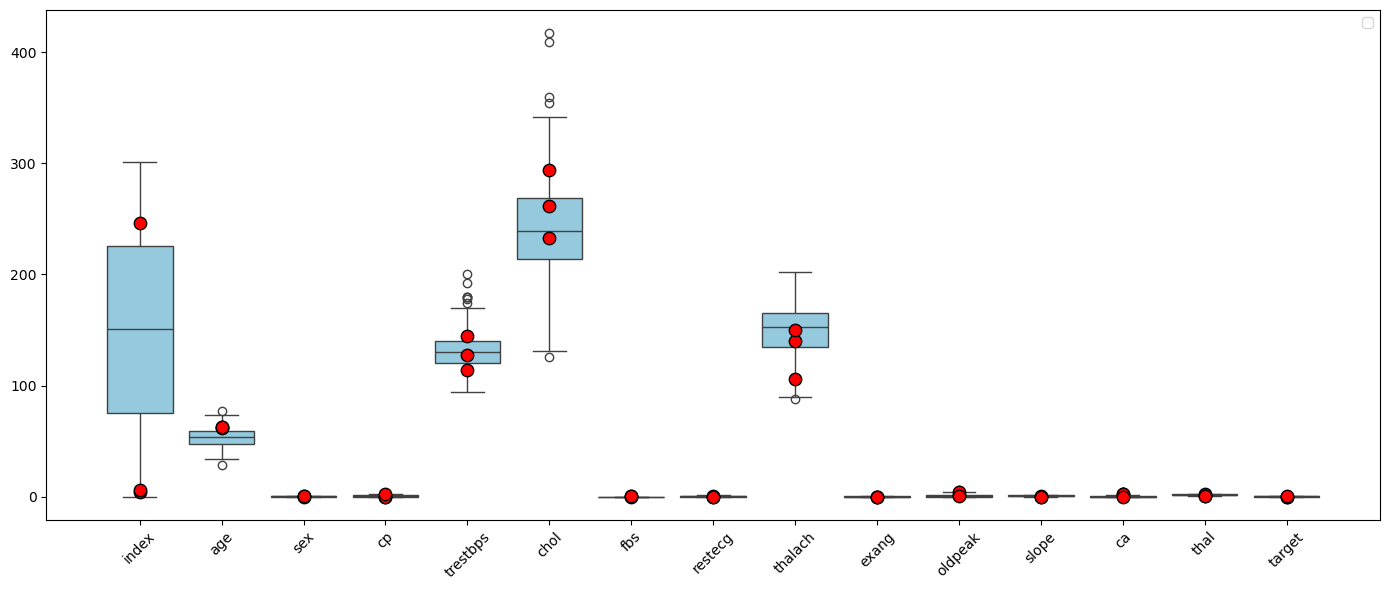

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 6))
sns.boxplot(data=heart_imputed.select_dtypes(include=np.number), color='skyblue')

indices_destacados = [4, 6, 246]

for i, col in enumerate(heart_imputed.select_dtypes(include=np.number).columns):
    y_vals = heart_imputed.loc[indices_destacados, col]
    plt.scatter(
        [i] * len(indices_destacados), 
        y_vals, 
        color='red', 
        s=80, 
        edgecolor='black', 
        zorder=10,
    )

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Ánalise de variáveis do tipo Numéricas contínuas

Analisando esses tipos de variáveis podemos identificar a tendência central, dispersão, outliers...
Colunas desse tipo:
* **age** (idade), **trestbps**(pressão arterial), **chol** (colesterol),**thalach** (frequência cardíaca máxima), **oldpeak** (depressão ST)

 Analisando somente a coluna da Idade:

In [202]:
df = heart_imputed.copy() # Cópia para análise

In [203]:
df["age"].describe()


count    301.000000
mean      53.855150
std        8.370887
min       29.000000
25%       48.000000
50%       54.000000
75%       59.000000
max       77.000000
Name: age, dtype: float64

Verificamos a idade min é de 29 e a máx é 77 anos, ou seja, não temos valores potenciais valores estranhos também.

In [204]:
df["sex"] = df["sex"].map({0: "Mulher", 1: "Homem"})


### Análise da distribuição da coluna idade (em anos)

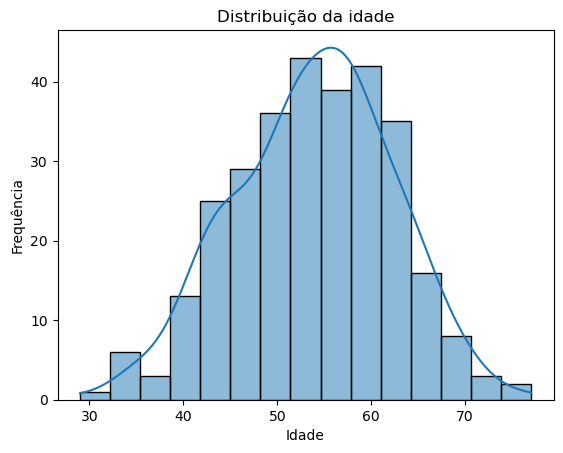

In [205]:
#Distribuição de idade
sns.histplot(df["age"],kde=True)
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.title("Distribuição da idade")
plt.show()


In [206]:
import altair as alt
#Grafico da quantidade de homens e mulheres
alt.Chart(df).mark_bar().encode(
    x=alt.X('sex:O', title='Sexo'),
    y=alt.Y('count():Q', title='Quantidade'),
).properties(
    title='Quantidade por Sexo',
    width=300, #largura
    height=600 #altura
)

alt.Chart(...)

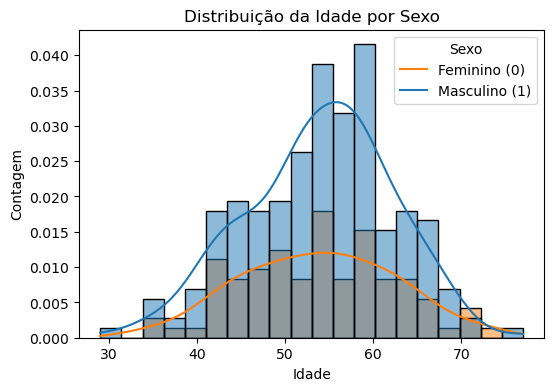

Estatística t: 0.08837723933561331
p-valor: 0.9296847907705192
Não há diferença significativa na idade média entre homens e mulheres.


In [207]:
import seaborn as sns
import matplotlib.pyplot as plt
# Distribuição das idades por sexo
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="age", hue="sex", kde=True, bins=20, alpha=0.5,stat="density" )
plt.title("Distribuição da Idade por Sexo")
plt.xlabel("Idade")
plt.ylabel("Contagem")
plt.legend(title="Sexo", labels=["Feminino (0)", "Masculino (1)"])
plt.show()

# Teste t
from scipy.stats import ttest_ind

idade_homens = df[df["sex"] == "Homem"]["age"]
idade_mulheres = df[df["sex"] == "Mulher"]["age"]

t_stat, p_value = ttest_ind(idade_homens, idade_mulheres, equal_var=False)

print("Estatística t:", t_stat)
print("p-valor:", p_value)

if p_value < 0.05:
    print("Há diferença significativa na idade média entre homens e mulheres.")
else:
    print("Não há diferença significativa na idade média entre homens e mulheres.")

In [208]:
df.groupby("sex")["age"].describe()


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Homem,210.0,53.883810,8.259605,29.0,48.7,54.0,59.0,77.0
Mulher,91.0,53.789011,8.668429,34.0,47.7,54.0,60.0,74.0


Análise: Há uma indicação de que as mulheres do estudo são, em geral, mais velhas. Como a idade é **fator de risco** para problemas cardíacos, isso pode influenciar os resultados clínicos (ex: pressão alta, angina, defeitos eletrocardiográficos) das mulheres.

In [209]:
import pandas as pd

# Ajuste os bins conforme o range das idades do seu dataset
bins = [29, 40, 50, 60, 70, 80]
labels = ['30-40', '41-50', '51-60', '61-70', '71-80']

df['Faixa_Idade'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)


In [210]:
tabela = df.groupby(['Faixa_Idade', 'sex', 'cp']).size().unstack(fill_value=0)
print(tabela)


cp                  0.0  1.0  2.0  3.0
Faixa_Idade sex                       
30-40       Homem     4    3    2    2
            Mulher    0    1    3    0
41-50       Homem    16   19   12    3
            Mulher    4   11   14    0
51-60       Homem    50   27   20    7
            Mulher   13    7   13    4
61-70       Homem    28    5    7    3
            Mulher    8    4    5    0
71-80       Homem     1    0    0    0
            Mulher    1    1    2    0


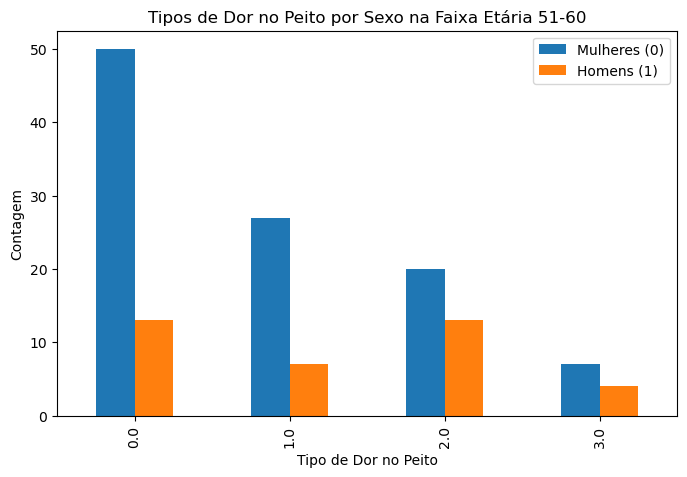

In [211]:
import matplotlib.pyplot as plt

faixa = '51-60'
dados_faixa = df[df['Faixa_Idade'] == faixa]

# Contar tipos de dor no peito por sexo
contagem = dados_faixa.groupby(['cp', 'sex']).size().unstack()

contagem.plot(kind='bar', figsize=(8,5))
plt.title(f'Tipos de Dor no Peito por Sexo na Faixa Etária {faixa}')
plt.xlabel('Tipo de Dor no Peito')
plt.ylabel('Contagem')
plt.legend(['Mulheres (0)', 'Homens (1)'])
plt.show()


Contagem absoluta:
sex  Homem  Mulher
cp                
0.0     50      13
1.0     27       7
2.0     20      13
3.0      7       4

Proporções (% dentro do sexo):
sex  Homem  Mulher
cp                
0.0   48.1    35.1
1.0   26.0    18.9
2.0   19.2    35.1
3.0    6.7    10.8


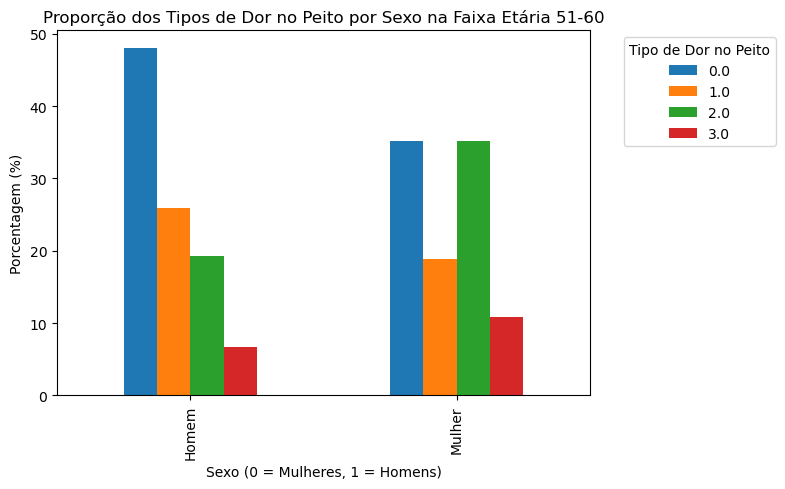

In [212]:
import pandas as pd
import matplotlib.pyplot as plt


faixa = '51-60'
df_faixa = df[df['Faixa_Idade'] == faixa]

# Conta o total por sexo para calcular as proporções
total_por_sexo = df_faixa.groupby('sex').size()

# Conta quantos para cada tipo de dor no peito por sexo
contagem = df_faixa.groupby(['cp', 'sex']).size().unstack(fill_value=0)

# Calcula a proporção dentro de cada sexo
proporcoes = contagem.div(total_por_sexo, axis=1) * 100  # em porcentagem

print("Contagem absoluta:")
print(contagem)
print("\nProporções (% dentro do sexo):")
print(proporcoes.round(1))


proporcoes.T.plot(kind='bar', figsize=(8,5))
plt.title(f'Proporção dos Tipos de Dor no Peito por Sexo na Faixa Etária {faixa}')
plt.xlabel('Sexo (0 = Mulheres, 1 = Homens)')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Tipo de Dor no Peito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [213]:
df[['age','trestbps','chol','thalach','oldpeak']].describe()


,age,trestbps,chol,thalach,oldpeak
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,53.855150,131.922924,242.516944,149.699668,1.022658
std,8.370887,16.405793,43.874960,21.215118,1.112916
min,29.000000,94.000000,126.000000,88.000000,0.000000
25%,48.000000,120.000000,213.600000,134.800000,0.000000
50%,54.000000,130.000000,239.000000,153.200000,0.640000
75%,59.000000,140.000000,269.000000,165.200000,1.600000
max,77.000000,200.000000,417.000000,202.000000,6.200000


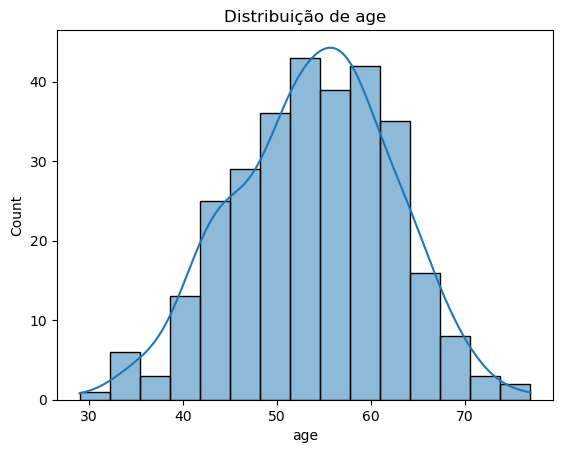

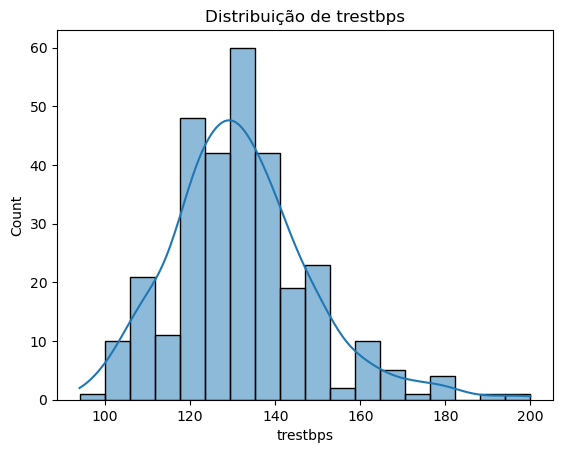

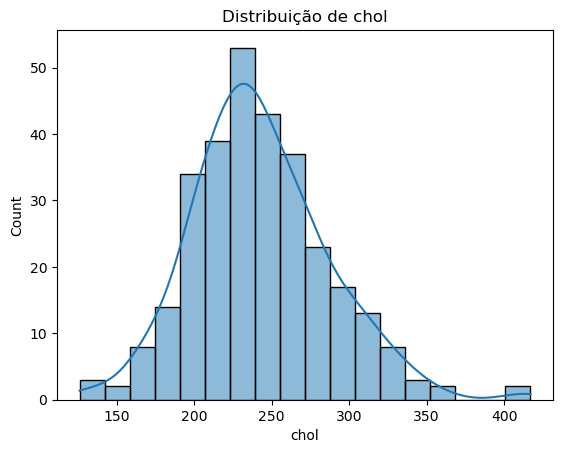

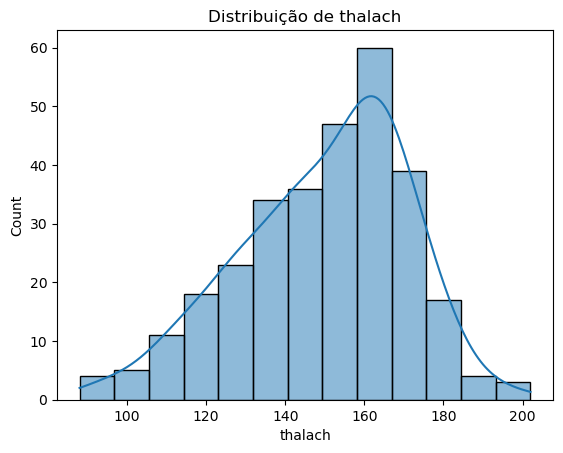

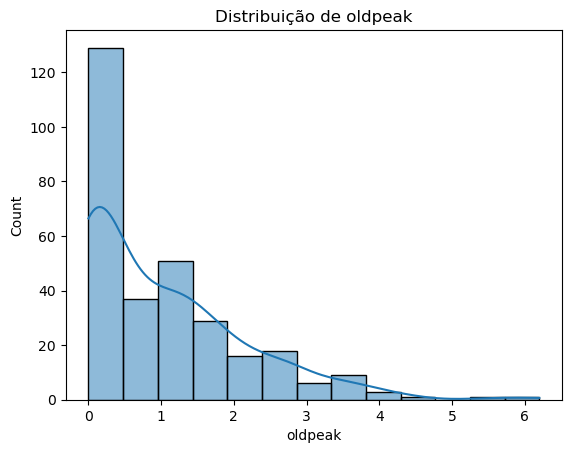

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['age','trestbps','chol','thalach','oldpeak']:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()


# Análise
* A distribuição de idades dos pacientes em nosso conjunto de dados revela que a maioria se concentra na faixa etária entre 50 e 60 anos. Essa concentração é clinicamente relevante, pois esta faixa etária é conhecida por apresentar maior incidência de problemas relacionados à saúde do coração.

* A pressão arterial se refere a força que o sangue exerce nas paredes das artérias quando é impulsionado pelo coração para ser levado a todo o corpo.

Em uma análise inicial dos dados de pressão arterial, focando especificamente na pressão sistólica, observamos as seguintes classificações de referência:

    Normal: Abaixo de 120 mmHg.
    Pré-hipertensão: Entre 120-139 mmHg.
    Hipertensão Estágio 1: Entre 140-159 mmHg.
    Hipertensão Estágio 2: Acima de 160 mmHg.

Ao analisar a distribuição da nossa amostra de pacientes, notamos que a grande maioria dos valores dos dados está concentrada na faixa entre 120 e 140 mmHg. Isso nos coloca majoritariamente nas categorias de pré-hipertensão e início da hipertensão estágio 1, que são, essencialmente, os estágios iniciais de um problema mais sério de saúde cardiovascular, indicando a necessidade de intervenção e monitoramento imediatos.

* Colesterol: A maior parte dos pacientes analisados apresenta Colesterol Total elevado, na faixa considerada limítrofe a alta (200 a 300 mg/dL).

Existe uma correlação a ser analisada: se esses pacientes, com esses níveis de colesterol, apresentam doença cardíaca, isso reforça a tese médica de que níveis elevados de colesterol total são um fator de risco significativo e estão associados a desfechos negativos (a presença da doença).

* A variável oldpeak representa a depressão do segmento ST observada durante o teste de esforço em relação ao repouso. Valores próximos de 0 indicam ausência de alteração significativa, enquanto valores maiores refletem maior nível de isquemia miocárdica, ou seja, um indício de menor oxigenação do músculo cardíaco durante o exercício.

Ao observar o histograma dessa variável, nota-se uma forte concentração de valores próximos de 0, com poucos casos apresentando valores mais altos (acima de 2). Essa distribuição assimétrica à direita sugere que a maioria dos pacientes do conjunto de dados não apresentou sinais de anormalidade cardíaca significativa, enquanto apenas uma pequena parcela apresentou valores que podem indicar condições mais graves.

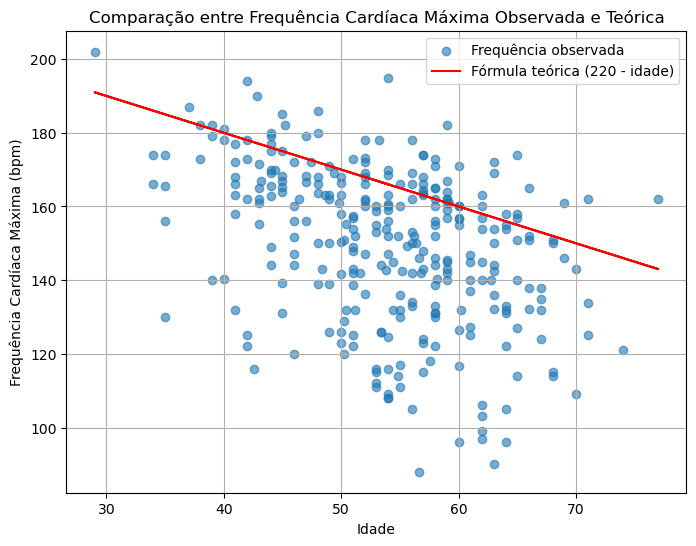

In [215]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o seu DataFrame se chame df
# e que as colunas sejam 'age' e 'thalach'

# Calcula a frequência máxima teórica
df['max_teorica'] = 220 - df['age']

# Cria o gráfico
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['thalach'], alpha=0.6, label='Frequência observada')
plt.plot(df['age'], df['max_teorica'], color='red', label='Fórmula teórica (220 - idade)')
plt.xlabel('Idade')
plt.ylabel('Frequência Cardíaca Máxima (bpm)')
plt.title('Comparação entre Frequência Cardíaca Máxima Observada e Teórica')
plt.legend()
plt.grid(True)
plt.show()


A variável thalach representa a frequência cardíaca máxima observada para cada indivíduo do conjunto de dados. Para verificar a coerência dos valores registrados, foi realizada uma comparação com a frequência cardíaca máxima teórica, obtida pela fórmula 220−idade. Essa análise exploratória permitiu observar o comportamento da frequência cardíaca em relação à idade, avaliando se os dados seguem o padrão esperado de diminuição da frequência máxima conforme o aumento da idade. Além disso, a comparação auxilia na identificação de possíveis outliers ou registros inconsistentes, contribuindo para a compreensão da distribuição e da qualidade dos dados.

<Axes: xlabel='oldpeak'>

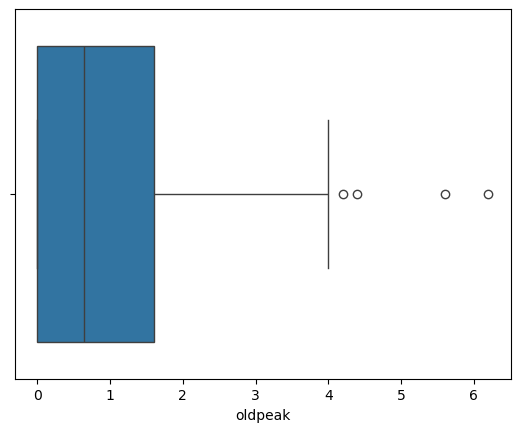

In [216]:
import seaborn as sns
sns.boxplot(x=df['oldpeak'])



<Axes: >

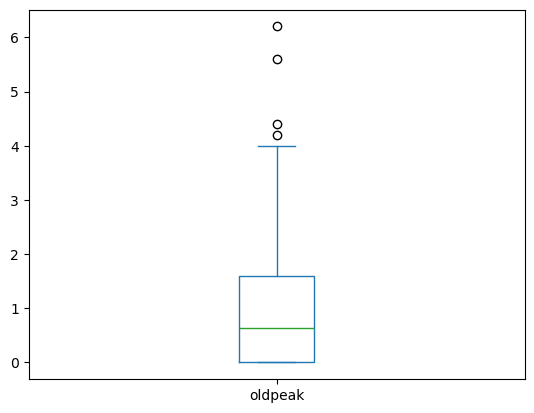

In [217]:
df['oldpeak'].plot.box()


In [218]:
Q1 = df['oldpeak'].quantile(0.25)
Q3 = df['oldpeak'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
df[df['oldpeak'] > limite_superior]


,index,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Faixa_Idade,max_teorica
6,6,62.8,Homem,0.0,114.0,261.2,0,0.0,140.0,0,4.4,0.0,3.0,1.0,0.0,61-70,157.2
13,13,51.0,Homem,0.0,140.0,298.0,0,1.0,122.0,1,4.2,1.0,3.0,3.0,0.0,51-60,169.0
51,51,55.0,Homem,0.0,146.8,217.0,0,1.0,111.0,0,5.6,1.0,1.0,3.0,0.0,51-60,165.0
63,63,62.0,Mulher,0.0,160.0,164.0,0,0.0,145.0,0,6.2,0.0,2.0,3.0,0.0,61-70,158.0


In [219]:
df['sex'].value_counts(normalize=True) * 100
df['cp'].value_counts()


cp
0.0    125
1.0     79
2.0     78
3.0     19
Name: count, dtype: int64

In [220]:
import altair as alt

alt.Chart(df).mark_bar().encode(
    x=alt.X('count()', title='Contagem'),
    y=alt.Y('cp:O', title='Tipo de dor no peito'),
    color='cp:N'
).properties(title='Distribuição de tipo de dor no peito')


alt.Chart(...)

## Análise de dados do tipo Numérica discreta



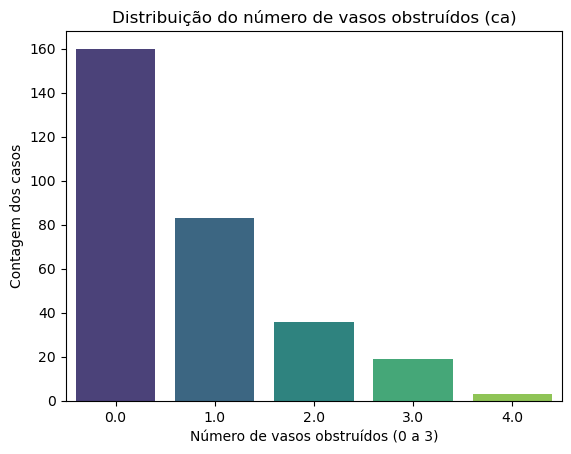

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='ca', data=df, palette='viridis')
plt.title('Distribuição do número de vasos obstruídos (ca)')
plt.xlabel('Número de vasos obstruídos (0 a 3)')
plt.ylabel('Contagem dos casos')
plt.show()


In [222]:
freq_ca = df['ca'].value_counts().sort_index()
percent_ca = df['ca'].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({'Frequência Absoluta': freq_ca, 'Frequência Relativa (%)': percent_ca.round(2)})


,Frequência Absoluta,Frequência Relativa (%)
ca,,
0.0,160,53.16
1.0,83,27.57
2.0,36,11.96
3.0,19,6.31
4.0,3,1.00


In [223]:
df['ca'].describe()


count    301.000000
mean       0.744186
std        0.964887
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        4.000000
Name: ca, dtype: float64

A coluna `ca` representa quantos vasos principais (entre 0 e 3) mostraram obstração. Caso haja valores maiores isso pode indicar maior gravidade da doença coronariana.
Nesse caso, uma análise posterior pode ser feita relacionando com a coluna do colesterol e com a coluna que representa o tipo de dor no peito, para identificarmos possíveis relações entre essas variáveis.
* Com a estatística descritiva verificamos que a média está mais próxima de 0,ou seja, **a maioria com poucos vasos obstruídos**;  

Assim pela análise, a variável `ca` apresenta distribuição assimétrica, com a maioria dos pacientes possuindo poucos vasos obstruídos (valores próximos de 0). Pacientes com valores mais altos de ca são minoria, mas podem indicar casos de doença cardíaca mais grave. Essa tendência poderá ser confirmada explorando a relação entre ca e a variável-alvo `target`.

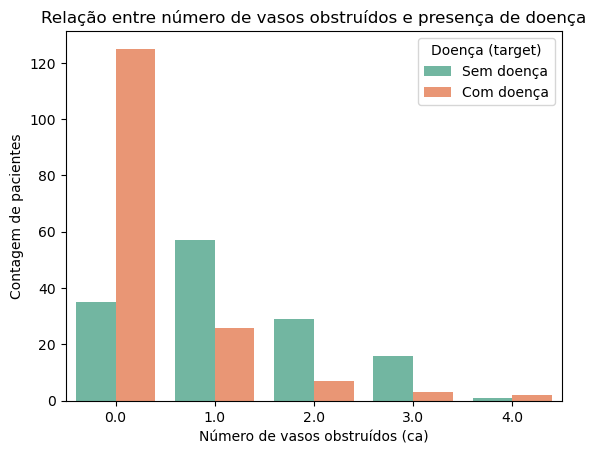

In [224]:
sns.countplot(x='ca', hue='target', data=df, palette='Set2')
plt.title('Relação entre número de vasos obstruídos e presença de doença')
plt.xlabel('Número de vasos obstruídos (ca)')
plt.ylabel('Contagem de pacientes')
plt.legend(title='Doença (target)', labels=['Sem doença', 'Com doença'])
plt.show()


Ao comparar `ca` com a variável-alvo (`target`), observou-se que muitas pessoas diagnosticadas com doença cardíaca (`target = 1`) também possuem `ca = 0`. Isso sugere que a presença de doença nem sempre está associada à obstrução detectável em grandes vasos, podendo envolver outros fatores cardíacos funcionais. Assim, `ca` isoladamente não distingue bem entre indivíduos saudáveis e doentes, mas pode ter importância combinada com outras variáveis clínicas.

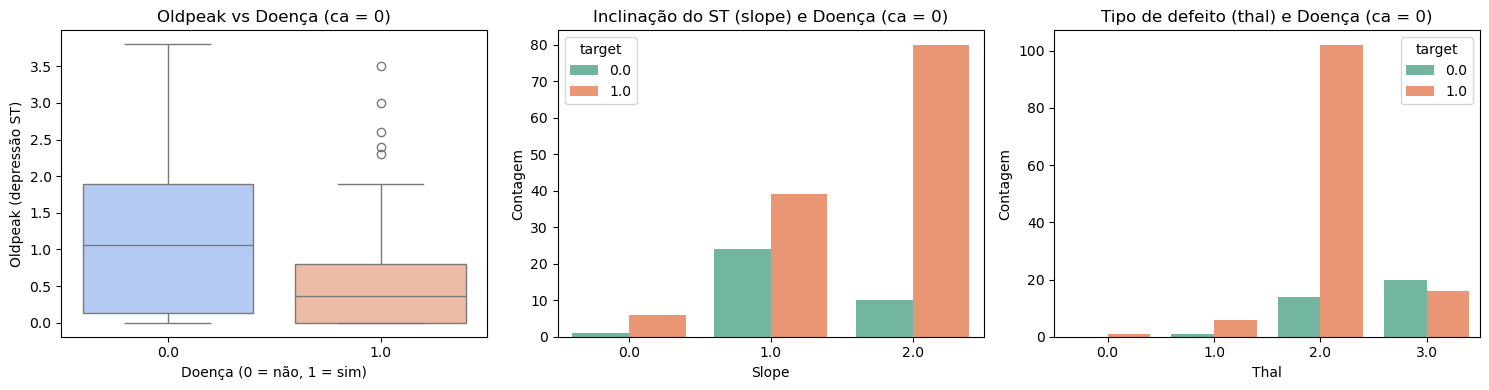

In [225]:
df_sem_obstrucao = df[df['ca'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# oldpeak
sns.boxplot(x='target', y='oldpeak', data=df_sem_obstrucao, palette='coolwarm', ax=axes[0])
axes[0].set_title('Oldpeak vs Doença (ca = 0)')
axes[0].set_xlabel('Doença (0 = não, 1 = sim)')
axes[0].set_ylabel('Oldpeak (depressão ST)')

# slope
sns.countplot(x='slope', hue='target', data=df_sem_obstrucao, palette='Set2', ax=axes[1])
axes[1].set_title('Inclinação do ST (slope) e Doença (ca = 0)')
axes[1].set_xlabel('Slope')
axes[1].set_ylabel('Contagem')

# thal
sns.countplot(x='thal', hue='target', data=df_sem_obstrucao, palette='Set2', ax=axes[2])
axes[2].set_title('Tipo de defeito (thal) e Doença (ca = 0)')
axes[2].set_xlabel('Thal')
axes[2].set_ylabel('Contagem')

plt.tight_layout()
plt.show()


**Entre os que não têm obstrução nos vasos, quais fatores funcionais indicam doença?**

Para compreender por que muitos indivíduos com ca = 0 ainda apresentam diagnóstico positivo de doença, foram analisadas variáveis clínicas associadas à função cardíaca, como oldpeak , slope e thal.
Observou-se que indivíduos com valores 1 ou 2 de slope e com defeitos reversíveis (thal = 2) apresentam maior incidência de doença, mesmo sem obstrução visível nos grandes vasos. Esses achados sugerem que a detecção de anormalidades elétricas ou funcionais do coração também desempenha papel importante no diagnóstico, complementando as informações fornecidas por ca.

## Análise das variáveis do tipo categóricas nominais

No dataset são: `sex, cp, restecg, thal, terget`

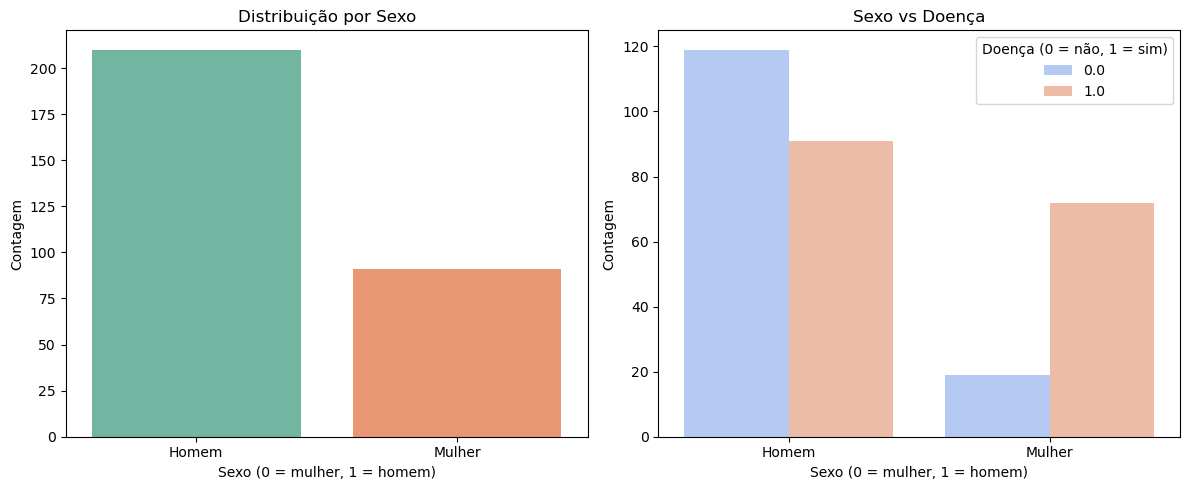

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Distribuição de sexos
sns.countplot(x='sex', data=df, palette='Set2', ax=ax[0])
ax[0].set_title('Distribuição por Sexo')
ax[0].set_xlabel('Sexo (0 = mulher, 1 = homem)')
ax[0].set_ylabel('Contagem')

# Relação entre sexo e presença de doença
sns.countplot(x='sex', hue='target', data=df, palette='coolwarm', ax=ax[1])
ax[1].set_title('Sexo vs Doença')
ax[1].set_xlabel('Sexo (0 = mulher, 1 = homem)')
ax[1].set_ylabel('Contagem')
ax[1].legend(title='Doença (0 = não, 1 = sim)')

plt.tight_layout()
plt.show()


In [227]:
# Agrupa por sexo e calcula a taxa de doença dentro de cada grupo
sex_stats = df.groupby('sex')['target'].mean()
sex_stats.index = sex_stats.index.map({0: 'Mulheres', 1: 'Homens'})
sex_stats = (
    df.groupby('sex')['target']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Total', 'sum': 'Com doença', 'mean': 'Proporção_doença'})
)

sex_stats['Proporção_doença'] = (sex_stats['Proporção_doença'] * 100).round(2)

sex_stats


,Total,Com doença,Proporção_doença
sex,,,
Homem,210,91.0,43.33
Mulher,91,72.0,79.12


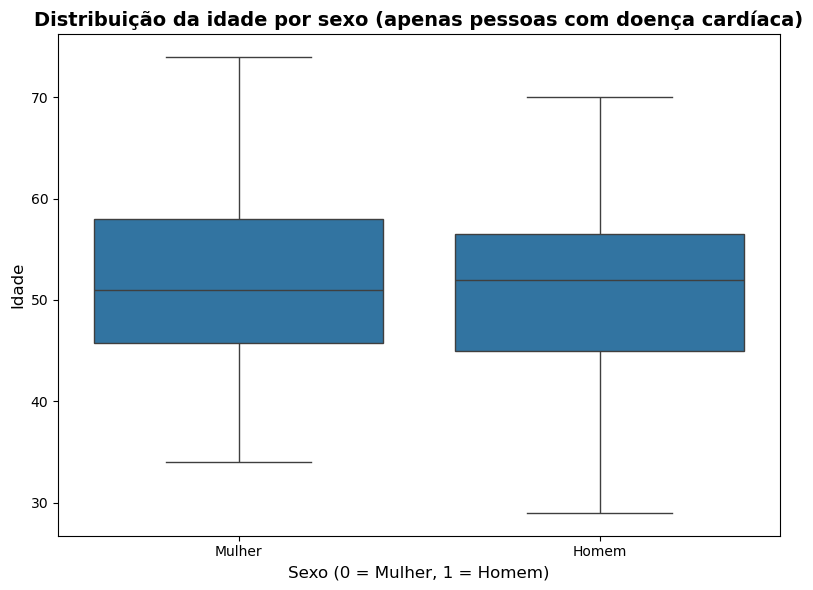

In [228]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtra apenas quem tem doença cardíaca
df_disease = df[df['target'] == 1].copy()

# Gráfico: distribuição das idades by sex for people with heart disease
plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='age', data=df_disease)

plt.title('Distribuição da idade por sexo (apenas pessoas com doença cardíaca)', fontsize=14, weight='bold')
plt.xlabel('Sexo (0 = Mulher, 1 = Homem)', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.xticks([0, 1], ['Mulher', 'Homem']) # Set the tick labels
plt.tight_layout()
plt.show()

A análise revelou que, embora o conjunto de dados apresente um número maior de homens, **a proporção de mulheres com doença cardíaca é superior**. No entanto, ao relacionar essa informação com a idade, observou-se que as **mulheres acometidas pela doença tendem a ser mais velhas**, enquanto os **homens manifestam a condição em idades mais jovens**. Esse comportamento sugere que a diferença de prevalência entre os sexos pode estar associada à faixa etária, **reforçando a hipótese de que as doenças cardíacas surgem mais tardiamente nas mulheres e de forma mais antecipada nos homens.**

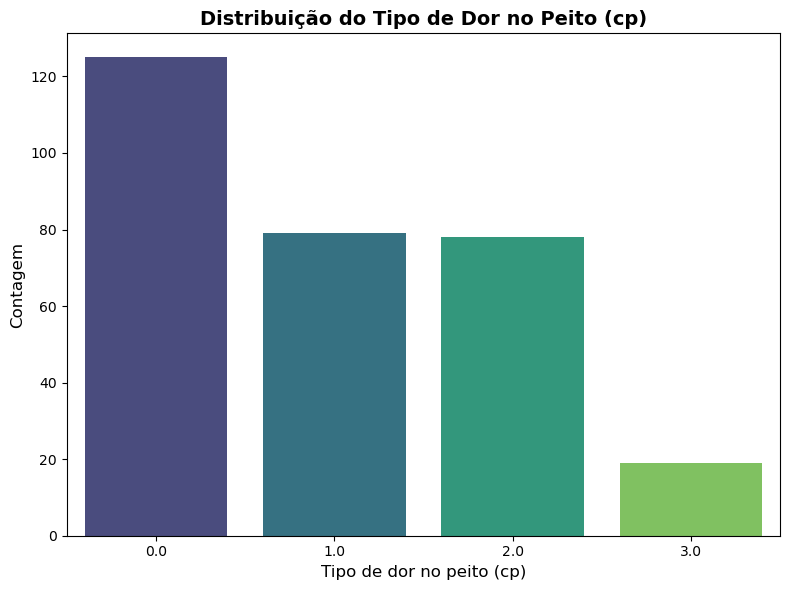

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='cp', data=df, palette='viridis')

plt.title('Distribuição do Tipo de Dor no Peito (cp)', fontsize=14, weight='bold')
plt.xlabel('Tipo de dor no peito (cp)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.tight_layout()
plt.show()


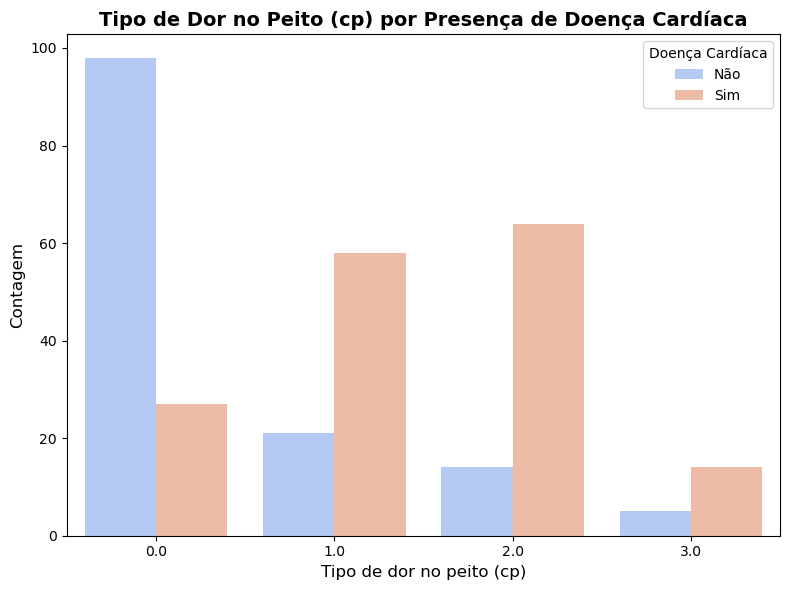

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(
    x='cp', hue='target', data=df, palette='coolwarm'
)

plt.title('Tipo de Dor no Peito (cp) por Presença de Doença Cardíaca', fontsize=14, weight='bold')
plt.xlabel('Tipo de dor no peito (cp)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.legend(title='Doença Cardíaca', labels=['Não', 'Sim'])
plt.tight_layout()
plt.show()


A variável cp representa o tipo de dor no peito, variando de 0 (angina típica) até 3 (assintomático).
Ao analisar o conjunto de dados, observa-se que à medida que o valor de cp aumenta, também aumenta a proporção de indivíduos com doença cardíaca.
Ou seja, pessoas com cp = 0 tendem a não apresentar a doença, enquanto aquelas com cp = 2 e cp = 3 (dor não anginosa ou ausência de dor) têm maior probabilidade de diagnóstico positivo.

Esse padrão sugere que, neste dataset, a presença de sintomas típicos de dor no peito nem sempre indica maior risco, enquanto casos assintomáticos ou com dores atípicas estão mais associados à doença, possivelmente refletindo diagnósticos feitos em estágios mais avançados ou com base em outros fatores clínicos.

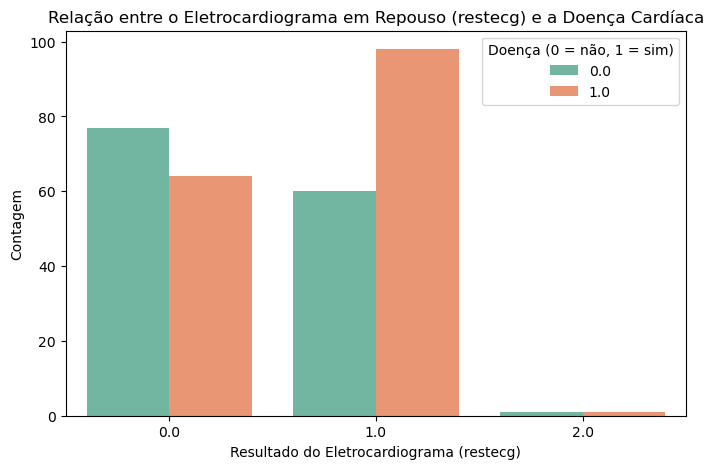

In [231]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='restecg', hue='target', data=df, palette='Set2')
plt.title('Relação entre o Eletrocardiograma em Repouso (restecg) e a Doença Cardíaca')
plt.xlabel('Resultado do Eletrocardiograma (restecg)')
plt.ylabel('Contagem')
plt.legend(title='Doença (0 = não, 1 = sim)')
plt.show()


In [232]:
# Calculando a proporção de doença em cada categoria de restecg
restecg_stats = df.groupby('restecg')['target'].agg(
    Total='count',
    Com_doenca='sum'
)
restecg_stats['Proporcao_doenca'] = (restecg_stats['Com_doenca'] / restecg_stats['Total']) * 100
print(restecg_stats)


         Total  Com_doenca  Proporcao_doenca
restecg                                     
0.0        141        64.0         45.390071
1.0        158        98.0         62.025316
2.0          2         1.0         50.000000


A análise da variável **restecg** (resultado do eletrocardiograma em repouso) mostra que a maioria dos indivíduos se enquadra nas categorias 0 e 1. Observa-se que pessoas com **restecg = 1**, indicando anormalidades no traçado do ECG, apresentam a **maior proporção de doença cardíaca aproximadamente 63%**, enquanto aquelas com **restecg = 0**, geralmente com ECG normal, têm uma proporção menor, cerca de 46%. Já o grupo com **restecg = 2**, associado a anormalidades mais específicas, é pequeno na amostra e apresenta uma proporção de 25%. Esses resultados sugerem que alterações detectadas no ECG em repouso estão associadas a maior probabilidade de presença de doença cardíaca.


In [233]:
import pandas as pd

contagem = {0: 0, 1: 0, 2: 0, 3: 0, 'NaN': 0, 'Outros': 0}

for val in df['thal']:
    if pd.isna(val):
        contagem['NaN'] += 1
    else:
        try:
            v = int(val)  # converte float para int, ex: 1.0 -> 1
            if v in contagem:
                contagem[v] += 1
            else:
                contagem['Outros'] += 1
        except:
            contagem['Outros'] += 1

print("Contagem dos valores na coluna 'thal':")
for chave, qtd in contagem.items():
    print(f"Valor {chave}: {qtd} linhas")


Contagem dos valores na coluna 'thal':
Valor 0: 1 linhas
Valor 1: 16 linhas
Valor 2: 174 linhas
Valor 3: 110 linhas
Valor NaN: 0 linhas
Valor Outros: 0 linhas


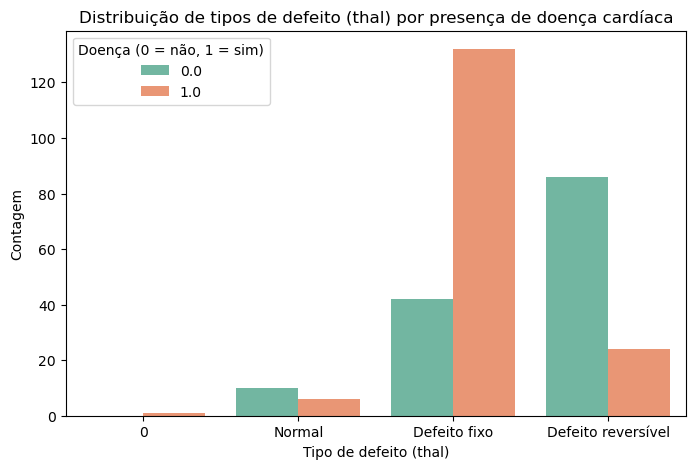

In [234]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapear valores para nomes claros
thal_labels = {0: '0', 1: 'Normal', 2: 'Defeito fixo', 3: 'Defeito reversível'}
df['thal_label'] = df['thal'].map(thal_labels)

plt.figure(figsize=(8,5))
sns.countplot(x='thal_label', hue='target', data=df, palette='Set2', order=['0', 'Normal', 'Defeito fixo', 'Defeito reversível'])

plt.title('Distribuição de tipos de defeito (thal) por presença de doença cardíaca')
plt.xlabel('Tipo de defeito (thal)')
plt.ylabel('Contagem')
plt.legend(title='Doença (0 = não, 1 = sim)')
plt.show()


In [235]:
tabela_thal = df.groupby('thal_label').agg(
    Total=('target', 'count'),
    Com_doenca=('target', 'sum')
)
tabela_thal['Proporcao_doenca'] = (tabela_thal['Com_doenca'] / tabela_thal['Total'] * 100).round(2)

print(tabela_thal)


                    Total  Com_doenca  Proporcao_doenca
thal_label                                             
0                       1         1.0            100.00
Defeito fixo          174       132.0             75.86
Defeito reversível    110        24.0             21.82
Normal                 16         6.0             37.50


A variável thal refere-se ao tipo de defeito observado no exame de tálio, que é um método utilizado para detectar problemas cardíacos através da perfusão do miocárdio. No dataset, essa variável é categorizada em quatro grupos:

* **Normal**: Ausência de defeito na perfusão (18 registros)

* **Defeito fixo**: Áreas do coração com perfusão permanentemente comprometida, indicando possível tecido cicatricial (165 registros)

* **Defeito reversível**: Áreas com perfusão reduzida apenas durante o estresse, sugerindo isquemia transitória (117 registros)

Analisando a relação com a presença de doença cardíaca:

* A maior proporção de pacientes com doença está no grupo de **defeito fixo (78,18%)**, o que é esperado, pois essa categoria indica danos permanentes no tecido cardíaco.

* O grupo de **defeito reversível** apresenta uma proporção de doença significativamente menor (23,93%), indicando que nem todos com este tipo de defeito possuem um diagnóstico confirmado de doença cardíaca.

* Curiosamente, o grupo classificado como normal também apresenta uma proporção de doença de 33,33%, o que pode indicar diagnósticos clínicos baseados em outros critérios ou possíveis limitações no exame de tálio.

Esses resultados ressaltam a importância da variável thal na avaliação diagnóstica, especialmente a presença de defeitos fixos que estão fortemente associados à doença cardíaca no conjunto de dados analisado. Ao mesmo tempo, evidencia que a variável, embora relevante, deve ser interpretada junto com outros indicadores clínicos para um diagnóstico mais completo. Já os casos da categoria 0, sugerem ser outliers no conjunto.

     Total  Com_doenca  Proporcao_doenca
fbs                                     
0      263       144.0         54.752852
1       38        19.0         50.000000


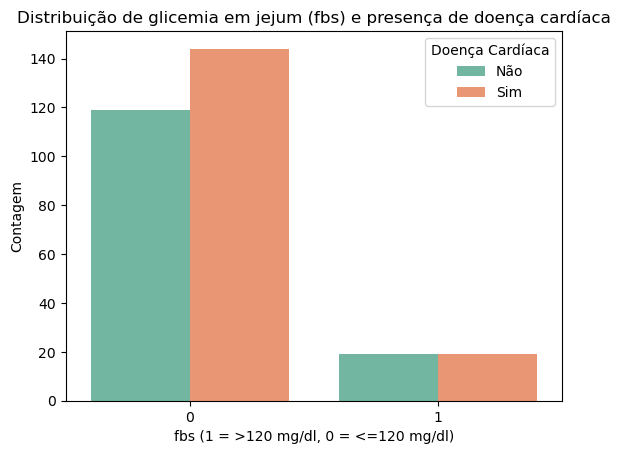

In [236]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tabela de frequência e proporção
tabela_fbs = df.groupby('fbs')['target'].agg(['count', 'sum'])
tabela_fbs.columns = ['Total', 'Com_doenca']
tabela_fbs['Proporcao_doenca'] = (tabela_fbs['Com_doenca'] / tabela_fbs['Total']) * 100
print(tabela_fbs)

# Gráfico
sns.countplot(x='fbs', hue='target', data=df, palette='Set2')
plt.title('Distribuição de glicemia em jejum (fbs) e presença de doença cardíaca')
plt.xlabel('fbs (1 = >120 mg/dl, 0 = <=120 mg/dl)')
plt.ylabel('Contagem')
plt.legend(title='Doença Cardíaca', labels=['Não', 'Sim'])
plt.show()


A variável fbs representa o nível de glicose no sangue em jejum, sendo codificada como:

* 0: menor ou igual a 120 mg/dl

* 1: maior que 120 mg/dl

Essa variável é utilizada como um indicador de possíveis distúrbios metabólicos, como a diabetes, que pode estar relacionada a um maior risco de doenças cardíacas.

Na análise, observa-se que indivíduos com níveis normais de glicose (fbs = 0) apresentam uma proporção de doença cardíaca de aproximadamente 54,9%, enquanto aqueles com níveis elevados (fbs = 1) possuem uma proporção levemente menor, de 51,1%.
Isso sugere que, **neste conjunto de dados**, o **nível de glicose em jejum não se mostrou um fator determinante isolado** na presença de doença cardíaca, já que as proporções de ocorrência são próximas. Contudo, essa variável pode ainda contribuir **em combinação com outras características clínicas**, como pressão arterial e colesterol, para indicar risco cardiovascular.

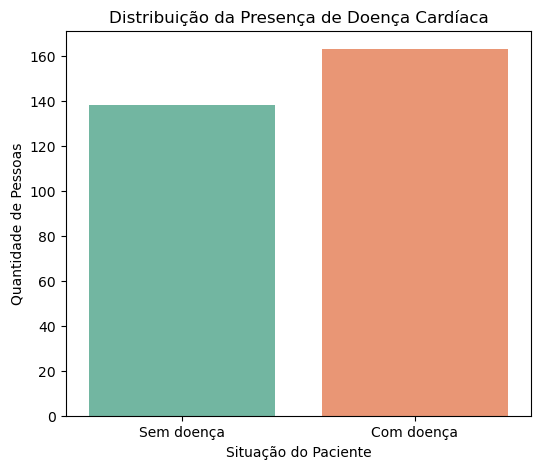

In [237]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeando para nomes mais compreensíveis
df['Doença Cardíaca'] = df['target'].map({0: 'Sem doença', 1: 'Com doença'})

# Gráfico de contagem
plt.figure(figsize=(6, 5))
sns.countplot(x='Doença Cardíaca', data=df, palette='Set2')
plt.title('Distribuição da Presença de Doença Cardíaca')
plt.xlabel('Situação do Paciente')
plt.ylabel('Quantidade de Pessoas')
plt.show()


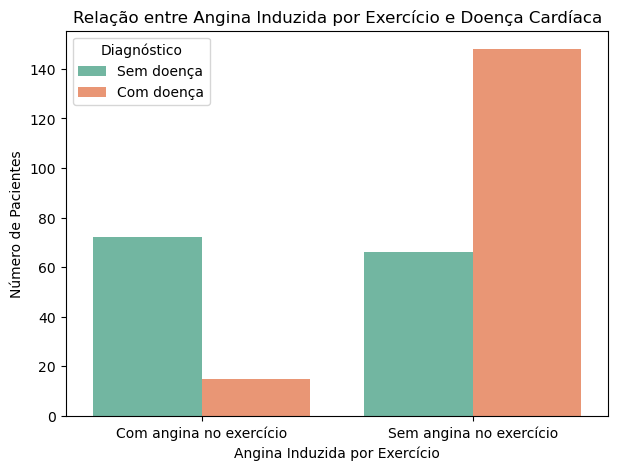

In [238]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeando para tornar os rótulos mais compreensíveis
df['Angina_exercicio'] = df['exang'].map({0: 'Sem angina no exercício', 1: 'Com angina no exercício'})
df['Doença Cardíaca'] = df['target'].map({0: 'Sem doença', 1: 'Com doença'})

plt.figure(figsize=(7, 5))
sns.countplot(x='Angina_exercicio', hue='Doença Cardíaca', data=df, palette='Set2')

plt.title('Relação entre Angina Induzida por Exercício e Doença Cardíaca')
plt.xlabel('Angina Induzida por Exercício')
plt.ylabel('Número de Pacientes')
plt.legend(title='Diagnóstico')
plt.show()


In [239]:
# Contagem de cada valor de exang
print(df['exang'].value_counts())

# Contagem cruzada entre exang e target
print(pd.crosstab(df['exang'], df['target'], margins=True))


exang
0    214
1     87
Name: count, dtype: int64
target  0.0  1.0  All
exang                
0        66  148  214
1        72   15   87
All     138  163  301


A variável **angina induzida por exercício (exang)** indica se o paciente apresentou dor no peito durante esforço físico (`1` para sim e `0` para não). Embora se espere que pacientes com angina induzida por exercício tenham maior incidência de doença cardíaca, a análise dos dados mostrou que muitos pacientes com doença cardíaca não apresentaram angina durante o exercício.

Isso evidencia que a angina induzida por exercício não é o único sintoma ou indicador de doença cardíaca, refletindo a complexidade clínica da doença e a variedade de suas manifestações. Portanto, a ausência de angina durante o exercício não exclui a possibilidade de diagnóstico positivo para doença cardíaca, reforçando a importância de uma avaliação clínica abrangente.

Além das considerações clínicas, não se pode descartar a possibilidade de inconsistências ou erros no dataset original, como codificações incorretas ou registros incompletos, que podem afetar a interpretação da variável **angina induzida por exercício (exang)**. Por isso, é importante tratar essa variável com cautela e, se possível, validar os dados com outras fontes ou informações clínicas complementares.

## **Conclusão da Análise Exploratória**

Nesta análise exploratória do dataset de doenças cardíacas, foram investigadas diversas variáveis de diferentes tipos (numéricas contínuas, discretas, categóricas, binárias e ordinais) em relação à presença ou ausência de doença cardíaca.

Os principais achados incluem:

* **Idade e sexo**: Observou-se que a proporção de mulheres com doença cardíaca é maior que a dos homens, porém as mulheres tendem a desenvolver a doença em idades mais avançadas, enquanto os homens apresentam diagnóstico em faixas etárias mais jovens.

* **Tipo de dor no peito (cp)**: Tipos de dor classificados como angina atípica, dor não anginosa e assintomática estão mais associados à presença de doença cardíaca, enquanto a angina típica aparece mais em pacientes sem doença, indicando uma relação relevante dessa variável com o diagnóstico.

* **Eletrocardiograma em repouso (restecg) e tipo de defeito no tálio (thal)**  mostraram correlações significativas com a presença da doença cardíaca. Em especial, a variável thal demonstrou que pacientes com defeito fixo possuem maior prevalência de doença (78%), enquanto os com defeito reversível apresentam uma proporção menor (24%). Pacientes com exame normal ainda apresentaram uma proporção considerável de diagnóstico (33%), o que sugere a necessidade de interpretação cuidadosa em conjunto com outras variáveis clínicas.

* **Glicemia em jejum (fbs) e angina induzida por exercício (exang)** mostraram resultados que indicam a necessidade de cautela na interpretação, pois apresentaram padrões não totalmente alinhados às expectativas clínicas, possivelmente por características específicas da amostra ou limitações do dataset.

* **Variáveis como pressão arterial, colesterol e oldpeak** indicam tendências esperadas, mas sem correlações muito fortes com a presença da doença, sugerindo que isoladamente podem não ser bons preditores.

Adicionalmente, observou-se a presença de categorias pouco frequentes ou dados ausentes em algumas variáveis, reforçando a importância de um pré-processamento cuidadoso para garantir qualidade e consistência nos dados utilizados para modelagem.

Por fim, esta análise exploratória fornece uma base sólida para entender o comportamento das variáveis e suas relações com a doença cardíaca, orientando as próximas etapas de modelagem e validação. Também destaca a importância de considerar possíveis limitações e peculiaridades do conjunto de dados para uma interpretação mais precisa.



## Modelos de classificação para `target`:

Trata-se de uma classificação binária, então podemos fazer diversos modelos, aqui trataremos desses:
- Regressão Linear
- LDA
- QDA
- Regressão Logística
- KNN
- SVM
- Rede Neural

Por fim faremos a comparação fiel entre os modelos e qual seria mais adequado para essa devida tarefa.

### Regressão Linear (Classificação)

In [240]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

- A ideia da utilizaçao de regressão linear para classificação é tentar prever a variável alvo como uma variável categórica alvo como uma variável contínua e usar um limiar a partir do qual classificaremos o alvo como categórico. Se temos duas classes para prever, uma aproximação:

In [241]:
heart_ds = heart_imputed # Apenas renomeando o nosso Dataset

OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.605
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     13.69
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           9.75e-28
Time:                        19:38:00   Log-Likelihood:                -54.220
No. Observations:                 210   AIC:                             152.4
Df Residuals:                     188   BIC:                             226.1
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

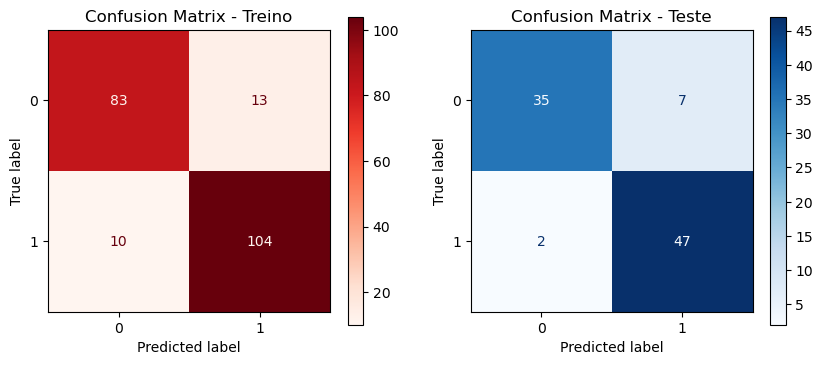

=== MÉTRICAS (Treino) ===
Acurácia:     0.890
Precisão:     0.889
Recall:       0.912

=== MÉTRICAS (Teste) ===
Acurácia:     0.901
Precisão:     0.870
Recall:       0.959


(0.9010989010989011, 0.8703703703703703, 0.9591836734693877)

In [242]:
# Dividindo o Dataset em vetor y e Matriz X

def Regressao_Linear(df = heart_ds, threshold = 0.5, verbose = True, varsout = [], treino_test = []):
    if not treino_test:
        X = df.drop(["target","index"], axis=1)
        y = heart_ds["target"]

        # Criando as variáveis Dummies para colunas categóricas
        categorical_cols = ['cp', 'thal', 'slope', 'restecg', "ca"]
        categorical_cols = [c for c in categorical_cols if c in X.columns]
        if len(categorical_cols) > 0:
            X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

        if varsout:
            X = X.drop(varsout, axis = 1)

        # Colocando todos os dados na mesma escala
        # Importante para métodos de regularização e melhora na estabilidade dos coeficientes
        scalizer = StandardScaler()
        X = pd.DataFrame(scalizer.fit_transform(X), columns=X.columns)

        X_const = sm.add_constant(X) # aciciona constante para o intercepto

        # Dividindo treino e teste
        X_train, X_test, y_train, y_test = train_test_split(X_const, y, test_size=0.3, random_state=200, stratify=y)
        X_train = X_train.astype(float)
        X_test = X_test.astype(float)
        y_train = y_train.astype(float)
        y_test = y_test.astype(float)
        X_train = X_train.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)

    else:
        X_train, X_test, y_train, y_test = treino_test

    model_ols = sm.OLS(y_train, X_train).fit()
    print("OLS (apenas diagnóstico) - R² e summary:")
    print(f"R² (train): {model_ols.rsquared:.3f}")
    print(model_ols.summary())
    print("\nmatriz de covariância dos coeficientes:")
    print(model_ols.cov_params())

    y_pred_train = model_ols.predict(X_train)
    y_pred_test  = model_ols.predict(X_test)

    y_pred_train = np.where(y_pred_train > threshold, 1, 0)
    y_pred_test  = np.where(y_pred_test  > threshold, 1, 0)

    for i in range(len(y_pred_train)):
        if y_pred_train[i] <= threshold:
            y_pred_train[i] = 0
        else:
            y_pred_train[i] = 1

    if verbose:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        cm = confusion_matrix(y_train, y_pred_train)
        cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        cm_display_train.plot(cmap=plt.cm.Reds, ax=axes[0])
        axes[0].set_title("Confusion Matrix - Treino")

        for i in range(len(y_pred_test)):
            if y_pred_test[i] <= 0.5:
                y_pred_test[i] = 0
            else:
                y_pred_test[i] = 1

        cm = confusion_matrix(y_test, y_pred_test)
        cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        cm_display_test.plot(cmap=plt.cm.Blues, ax=axes[1])
        axes[1].set_title("Confusion Matrix - Teste")
        plt.show()

    # --- Métricas de Treino ---
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train = recall_score(y_train, y_pred_train)

    if verbose:

        print("=== MÉTRICAS (Treino) ===")
        print(f"Acurácia:     {acc_train:.3f}")
        print(f"Precisão:     {prec_train:.3f}")
        print(f"Recall:       {rec_train:.3f}\n")

    # --- Métricas de Teste ---
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)

    if verbose:

        print("=== MÉTRICAS (Teste) ===")
        print(f"Acurácia:     {acc_test:.3f}")
        print(f"Precisão:     {prec_test:.3f}")
        print(f"Recall:       {rec_test:.3f}")

    return acc_test, prec_test, rec_test

Regressao_Linear()

In [243]:
def training_thresholds(model, acc_min = 0.9):
    thresholds = np.linspace(0, 1, 101)

    melhor_threshold = None
    melhor_recall = -1
    melhor_acc = -1  # nova variável

    resultados = []

    for t in thresholds:
        acc, prec, rec = model(threshold=t, verbose=False)
        resultados.append((t, acc, rec))
        if acc >= acc_min and rec > melhor_recall:
            melhor_threshold = t
            melhor_recall = rec
            melhor_acc = acc  # guarda a acurácia correspondente

    # Mostrar resultado final
    if melhor_threshold is not None:
        print(f"\nThreshold ótimo encontrado: {melhor_threshold:.2f}")
        print(f"Acurácia: {melhor_acc:.3f}")
        print(f"Recall máximo: {melhor_recall:.3f} (Acurácia ≥ {acc_min:.2f})")
    else:
        print("\nNenhum threshold atingiu a acurácia mínima desejada.")

        return melhor_threshold

training_thresholds(Regressao_Linear)


OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.605
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     13.69
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           9.75e-28
Time:                        19:38:00   Log-Likelihood:                -54.220
No. Observations:                 210   AIC:                             152.4
Df Residuals:                     188   BIC:                             226.1
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

Para seleção de Variáveis da nossa regressão linear faremos dois métodos:

- Backward Selection
- Regularização com Lasso

E verificaremos se conseguimos um modelo bom com menos variáveis

**Lasso :**

Melhor alpha (λ) encontrado: 0.011528

Coeficientes não nulos (variáveis selecionadas):
age                  -> -0.0164
sex                  -> -0.0869
chol                 -> -0.0262
exang                -> -0.0676
oldpeak              -> -0.1125
cp_1.0               -> 0.0832
cp_2.0               -> 0.1006
cp_3.0               -> 0.0632
thal_2.0             -> 0.0514
thal_3.0             -> -0.0243
slope_1.0            -> -0.0496
slope_2.0            -> 0.0134
ca_1.0               -> -0.0591
ca_2.0               -> -0.0496
ca_3.0               -> -0.0273


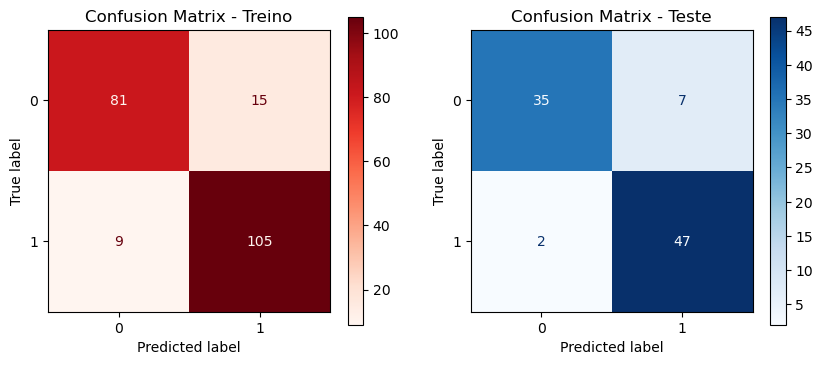

=== MÉTRICAS (Treino) ===
Acurácia: 0.886
Precisão: 0.875
Recall:   0.921

=== MÉTRICAS (Teste) ===
Acurácia: 0.901
Precisão: 0.870
Recall:   0.959


In [244]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ===========================================
# 1. Dividindo o Dataset
# ===========================================
X = heart_ds.drop(["target","index"], axis=1)
y = heart_ds["target"]

# Variáveis categóricas → dummies
categorical_cols = ['cp', 'thal', 'slope', 'restecg', "ca"]
categorical_cols = [c for c in categorical_cols if c in X.columns]
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
.86
# Escalonamento
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=200, stratify=y
)

# ===========================================
# 2. Ajuste do modelo LASSO com validação cruzada
# ===========================================
lasso_model = LassoCV(cv=10, random_state=42, n_jobs=-1)
lasso_model.fit(X_train, y_train)

print(f"Melhor alpha (λ) encontrado: {lasso_model.alpha_:.6f}")
print("\nCoeficientes não nulos (variáveis selecionadas):")
for name, coef in zip(X.columns, lasso_model.coef_):
    if coef != 0:
        print(f"{name:20s} -> {coef:.4f}")

# ===========================================
# 3. Predições e Avaliação
# ===========================================
y_pred_train = lasso_model.predict(X_train)
y_pred_test  = lasso_model.predict(X_test)

# Transformar em classificação binária (limiar 0.5)
y_pred_train = (y_pred_train > 0.5).astype(int)
y_pred_test  = (y_pred_test > 0.5).astype(int)

# ===========================================
# 4. Matrizes de confusão
# ===========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_train = confusion_matrix(y_train, y_pred_train)
ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Confusion Matrix - Treino")

cm_test = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Confusion Matrix - Teste")

plt.show()

# ===========================================
# 5. Métricas de desempenho
# ===========================================
print("=== MÉTRICAS (Treino) ===")
print(f"Acurácia: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Precisão: {precision_score(y_train, y_pred_train):.3f}")
print(f"Recall:   {recall_score(y_train, y_pred_train):.3f}")

print("\n=== MÉTRICAS (Teste) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_test):.3f}")
print(f"Precisão: {precision_score(y_test, y_pred_test):.3f}")
print(f"Recall:   {recall_score(y_test, y_pred_test):.3f}")


**Backward Selection :**

Fold 1: Removendo 'ca_4.0' (p-valor = 0.910)
Fold 1: Removendo 'thal_1.0' (p-valor = 0.890)
Fold 1: Removendo 'restecg_2.0' (p-valor = 0.760)
Fold 1: Removendo 'slope_2.0' (p-valor = 0.592)
Fold 1: Removendo 'thal_3.0' (p-valor = 0.555)
Fold 1: Removendo 'restecg_1.0' (p-valor = 0.418)
Fold 1: Removendo 'thalach' (p-valor = 0.320)
Fold 1: Removendo 'age' (p-valor = 0.448)
Fold 1: Removendo 'fbs' (p-valor = 0.267)
Fold 1: Removendo 'trestbps' (p-valor = 0.201)
Fold 1: Removendo 'ca_3.0' (p-valor = 0.181)


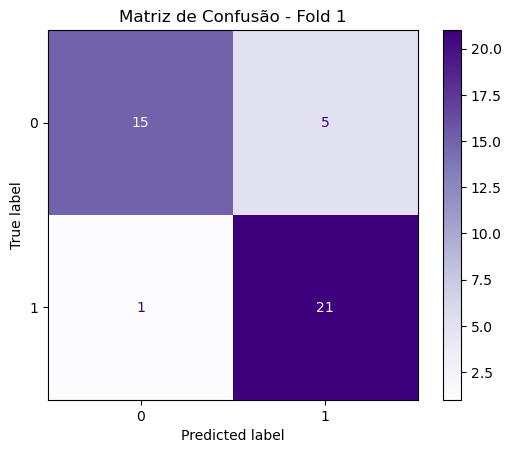

Fold 1 - Acc: 0.857 | Prec: 0.808 | Rec: 0.955 | F1: 0.875

Fold 2: Removendo 'ca_4.0' (p-valor = 0.916)
Fold 2: Removendo 'fbs' (p-valor = 0.826)
Fold 2: Removendo 'slope_2.0' (p-valor = 0.680)
Fold 2: Removendo 'trestbps' (p-valor = 0.696)
Fold 2: Removendo 'restecg_1.0' (p-valor = 0.611)
Fold 2: Removendo 'thal_1.0' (p-valor = 0.563)
Fold 2: Removendo 'thal_3.0' (p-valor = 0.898)
Fold 2: Removendo 'restecg_2.0' (p-valor = 0.433)
Fold 2: Removendo 'age' (p-valor = 0.347)
Fold 2: Removendo 'exang' (p-valor = 0.180)
Fold 2: Removendo 'ca_3.0' (p-valor = 0.162)
Fold 2: Removendo 'thalach' (p-valor = 0.177)
Fold 2: Removendo 'ca_1.0' (p-valor = 0.122)
Fold 2: Removendo 'ca_2.0' (p-valor = 0.253)


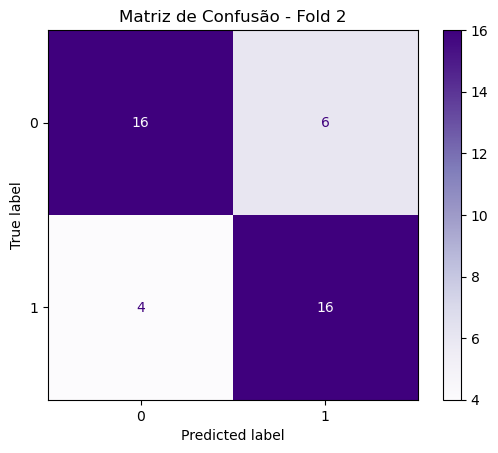

Fold 2 - Acc: 0.762 | Prec: 0.727 | Rec: 0.800 | F1: 0.762

Fold 3: Removendo 'ca_4.0' (p-valor = 0.997)
Fold 3: Removendo 'restecg_2.0' (p-valor = 0.971)
Fold 3: Removendo 'trestbps' (p-valor = 0.957)
Fold 3: Removendo 'slope_2.0' (p-valor = 0.693)
Fold 3: Removendo 'thalach' (p-valor = 0.624)
Fold 3: Removendo 'fbs' (p-valor = 0.516)
Fold 3: Removendo 'thal_1.0' (p-valor = 0.564)
Fold 3: Removendo 'thal_3.0' (p-valor = 0.937)
Fold 3: Removendo 'restecg_1.0' (p-valor = 0.472)
Fold 3: Removendo 'chol' (p-valor = 0.382)
Fold 3: Removendo 'ca_3.0' (p-valor = 0.183)
Fold 3: Removendo 'ca_2.0' (p-valor = 0.130)
Fold 3: Removendo 'exang' (p-valor = 0.072)
Fold 3: Removendo 'age' (p-valor = 0.069)


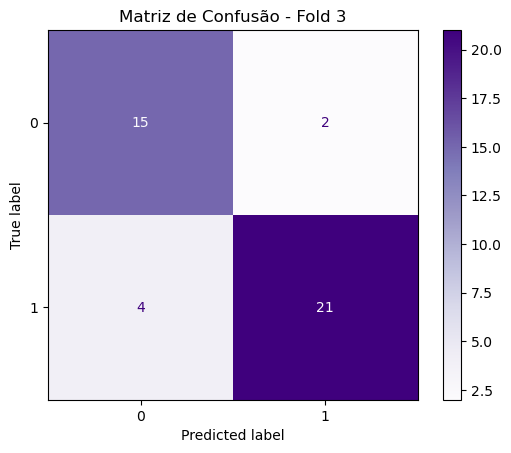

Fold 3 - Acc: 0.857 | Prec: 0.913 | Rec: 0.840 | F1: 0.875

Fold 4: Removendo 'ca_4.0' (p-valor = 0.958)
Fold 4: Removendo 'slope_2.0' (p-valor = 0.953)
Fold 4: Removendo 'trestbps' (p-valor = 0.885)
Fold 4: Removendo 'restecg_1.0' (p-valor = 0.854)
Fold 4: Removendo 'thal_1.0' (p-valor = 0.856)
Fold 4: Removendo 'fbs' (p-valor = 0.807)
Fold 4: Removendo 'chol' (p-valor = 0.712)
Fold 4: Removendo 'thal_3.0' (p-valor = 0.662)
Fold 4: Removendo 'restecg_2.0' (p-valor = 0.584)
Fold 4: Removendo 'age' (p-valor = 0.457)
Fold 4: Removendo 'thalach' (p-valor = 0.171)


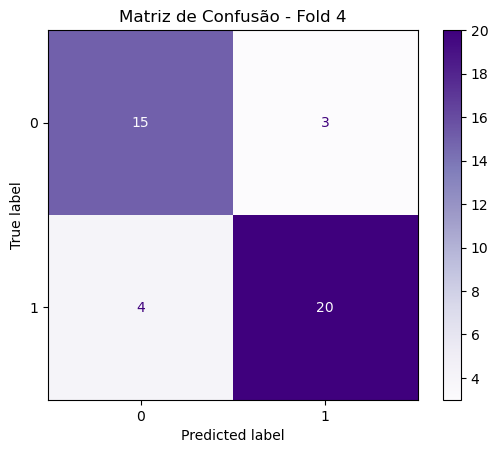

Fold 4 - Acc: 0.833 | Prec: 0.870 | Rec: 0.833 | F1: 0.851

Fold 5: Removendo 'thal_1.0' (p-valor = 0.997)
Fold 5: Removendo 'ca_4.0' (p-valor = 0.922)
Fold 5: Removendo 'slope_1.0' (p-valor = 0.688)
Fold 5: Removendo 'thal_2.0' (p-valor = 0.638)
Fold 5: Removendo 'trestbps' (p-valor = 0.665)
Fold 5: Removendo 'fbs' (p-valor = 0.619)
Fold 5: Removendo 'age' (p-valor = 0.609)
Fold 5: Removendo 'restecg_2.0' (p-valor = 0.591)
Fold 5: Removendo 'restecg_1.0' (p-valor = 0.539)
Fold 5: Removendo 'ca_3.0' (p-valor = 0.395)
Fold 5: Removendo 'thalach' (p-valor = 0.453)
Fold 5: Removendo 'slope_2.0' (p-valor = 0.116)
Fold 5: Removendo 'chol' (p-valor = 0.130)
Fold 5: Removendo 'thal_3.0' (p-valor = 0.093)


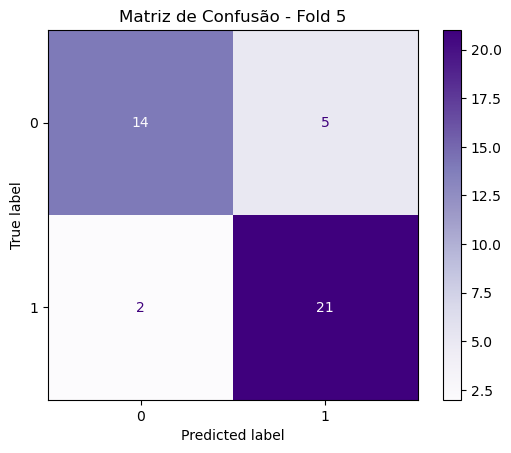

Fold 5 - Acc: 0.833 | Prec: 0.808 | Rec: 0.913 | F1: 0.857


=== Frequência de uso das variáveis nos folds ===
const                      1.00
sex                        1.00
oldpeak                    1.00
cp_1.0                     1.00
cp_2.0                     1.00
cp_3.0                     1.00
thal_2.0                   0.80
slope_1.0                  0.80
ca_1.0                     0.80
exang                      0.60
ca_2.0                     0.60
chol                       0.40
ca_3.0                     0.20
age                        0.00
trestbps                   0.00
fbs                        0.00
thalach                    0.00
thal_1.0                   0.00
thal_3.0                   0.00
slope_2.0                  0.00
restecg_1.0                0.00
restecg_2.0                0.00
ca_4.0                     0.00

=== Variáveis mais estáveis (≥ 60% dos folds) ===
['const', 'sex', 'exang', 'oldpeak', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'thal_2.0', 'slope_1.0', 'ca_1.0', 

In [245]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter

# ===============================
# 1. Divisão do dataset
# ===============================
X = heart_ds.drop(["target", "index"], axis=1)
y = heart_ds["target"]

# variáveis categóricas → dummies
categorical_cols = ['cp', 'thal', 'slope', 'restecg', "ca"]
categorical_cols = [c for c in categorical_cols if c in X.columns]
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# padronização
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# adiciona constante (intercepto)
X_const = sm.add_constant(X)

# divisão treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_const, y, test_size=0.3, random_state=200, stratify=y
)

X_train = X_train.astype(float).reset_index(drop=True)
X_test = X_test.astype(float).reset_index(drop=True)
y_train = y_train.astype(float).reset_index(drop=True)
y_test = y_test.astype(float).reset_index(drop=True)

# ===============================
# 2. Validação cruzada com backward selection
# ===============================
kf = KFold(n_splits=5, shuffle=True, random_state=360)

accuracies, precisions, recalls, f1s = [], [], [], []
fold = 1

# lista para guardar as variáveis finais de cada fold
selected_features_per_fold = []

for train_index, test_index in kf.split(X_train):
    X_train_cv = X_train.iloc[train_index].reset_index(drop=True)
    X_test_cv  = X_train.iloc[test_index].reset_index(drop=True)
    y_train_cv = y_train.iloc[train_index].reset_index(drop=True)
    y_test_cv  = y_train.iloc[test_index].reset_index(drop=True)

    # backward selection
    threshold = 0.05
    selected_X_train = X_train_cv.copy()
    selected_X_test  = X_test_cv.copy()

    while True:
        model_cv = sm.OLS(y_train_cv, selected_X_train).fit()
        pvals = model_cv.pvalues.drop("const", errors="ignore")

        if pvals.empty:
            break

        worst_var = pvals.idxmax()
        worst_pval = pvals.loc[worst_var]

        if worst_pval > threshold:
            print(f"Fold {fold}: Removendo '{worst_var}' (p-valor = {worst_pval:.3f})")
            selected_X_train = selected_X_train.drop(columns=[worst_var])
            if worst_var in selected_X_test.columns:
                selected_X_test = selected_X_test.drop(columns=[worst_var])
        else:
            break

    # garantir alinhamento
    selected_X_test = selected_X_test[selected_X_train.columns]

    # guarda as variáveis finais do fold
    selected_features_per_fold.append(selected_X_train.columns.tolist())

    # ajusta o modelo final do fold
    model_fold = sm.OLS(y_train_cv, selected_X_train).fit()

    # previsões
    y_pred = model_fold.predict(selected_X_test)
    y_pred_binary = (y_pred > 0.5).astype(int)

    # métricas
    acc = accuracy_score(y_test_cv, y_pred_binary)
    prec = precision_score(y_test_cv, y_pred_binary, zero_division=0)
    rec = recall_score(y_test_cv, y_pred_binary, zero_division=0)
    f1 = f1_score(y_test_cv, y_pred_binary, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    # matriz de confusão
    cm = confusion_matrix(y_test_cv, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Purples)
    plt.title(f"Matriz de Confusão - Fold {fold}")
    plt.show()

    print(f"Fold {fold} - Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}\n")
    fold += 1

# ===============================
# 3. Contagem das variáveis mais usadas
# ===============================
flat_features = [feat for sublist in selected_features_per_fold for feat in sublist]
freq = Counter(flat_features)
num_folds = len(selected_features_per_fold)

# frequência de presença em cada fold
feature_freq = {feat: freq[feat] / num_folds for feat in X_train.columns}

# ordena por frequência decrescente
sorted_features = sorted(feature_freq.items(), key=lambda x: x[1], reverse=True)

print("\n=== Frequência de uso das variáveis nos folds ===")
for feat, fr in sorted_features:
    print(f"{feat:25s}  {fr:.2f}")

# features mais estáveis (usadas em ≥ 60% dos folds)
stable_features = [feat for feat, fr in feature_freq.items() if fr >= 0.6]
print("\n=== Variáveis mais estáveis (≥ 60% dos folds) ===")
print(stable_features)

# ===============================
# 4. Avaliação final no conjunto de teste
# ===============================
X_train_stable = X_train[stable_features]
X_test_stable  = X_test[stable_features]

model_final = sm.OLS(y_train, X_train_stable).fit()
y_pred_test = model_final.predict(X_test_stable)
y_pred_test_binary = (y_pred_test > 0.5).astype(int)

acc_final = accuracy_score(y_test, y_pred_test_binary)
prec_final = precision_score(y_test, y_pred_test_binary, zero_division=0)
rec_final = recall_score(y_test, y_pred_test_binary, zero_division=0)
f1_final = f1_score(y_test, y_pred_test_binary, zero_division=0)

print("\n=== Avaliação final no conjunto de teste (usando variáveis mais estáveis) ===")
print(f"Acurácia:  {acc_final:.3f}")
print(f"Precisão:  {prec_final:.3f}")
print(f"Recall:    {rec_final:.3f}")
print(f"F1-score:  {f1_final:.3f}")


Vemos que as variáveis presentes em todos os clusters foram:

- const

- sex

- oldpeak

- cp_1

- cp_2

- cp_3

em seguida com 4-3 aparições temos:

- thal_2

- slope_1

- exang

- ca_2

já as outras ficaram com menos de 3 aparições

Vamos escolher as variáveis que apareceram em pelo menos 3 cluster para montar um problema simplificado.



In [246]:
vars_outbackward = ["age","trestbps","fbs","thalach","thal_1.0","thal_3.0","slope_2.0","restecg_1.0", "ca_4.0"]

In [247]:
# Modelo de regressão simplificado:

def Linear_Regress_simplify(threshold = 0.5,verbose = True, treino_test = []):
    return Regressao_Linear(threshold = threshold, verbose=False,varsout=vars_outbackward, treino_test = treino_test)

In [248]:
training_thresholds(Linear_Regress_simplify)

OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.598
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     22.44
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           3.66e-32
Time:                        19:38:02   Log-Likelihood:                -55.931
No. Observations:                 210   AIC:                             139.9
Df Residuals:                     196   BIC:                             186.7
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [249]:
# Redefinindo com threshold ótimo

def Linear_Regress_simplify(threshold = 0.46, verbose = True, treino_test = []):
    return Regressao_Linear(threshold = threshold, verbose=False,varsout=vars_outbackward, treino_test = treino_test)

Para comparar nosso modelo com outros, é importante obter uma estimativa mais robustas de seu desempenho médio.

Para isso, utilizaremos a validação cruzada `(cross-validation)`, aplicando a regressão linear em cinco divisões `(5-folds)` diferentes dos dados.

Esse método fornece uma estimativa mais confiável da performance média do modelo, pois reduz a influência da divisão específica dos dados em treino e teste, além de representar melhor sua capacidade de generalização ou seja, o risco de erro ao aplicar o modelo em novos dados.

## LDA - Análise Linear Discriminante

Após a abordagem inicial com a Regressão Linear como um classificador, passaremos agora para a Análise Linear Discriminante (LDA), um método que modela a classificação de maneira inerentemente estatística e mais robusta.

LDA é um algoritmo que assume que os dados de cada classe seguem uma distribuição Gaussiana (Normal) e que todas as classes compartilham da mesma matriz de covariância (ou seja, a mesma dispersão). A ideia central é:

Projetar os Dados: Encontrar um eixo (ou subespaço) que maximize a separação entre as médias das classes e minimize a variação dentro de cada classe.

Decisão: Classificar um novo ponto de dados na classe cuja média, ele está mais próximo após a projeção.

A principal vantagem do LDA é a sua capacidade de reduzir a dimensionalidade enquanto otimiza a separação entre as classes, tornando-o um classificador linear eficiente e interpretável. Para garantir a validade estatística do modelo, o Standard Scaling das variáveis contínuas é um passo obrigatório, pois o LDA é sensível à escala das variáveis

In [250]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
 
def LDA_model(threshold=0.5, verbose=True, treino_test = []):
   
    if not treino_test:
        # Separar Features (X) e Target (y)
        X = heart_ds.drop("target", axis=1)
        y = heart_ds["target"]

        # One-Hot Encoding
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
        categorical_cols = ['cp', 'thal', 'slope', 'restecg']

        X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

        # Escalonamento das variáveis contínuas
        cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]
        scaler = StandardScaler()
        X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Divisão Treino/Teste
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.3, random_state=42, stratify=y
        )

    else:
        X_train, X_test, y_train, y_test = treino_test
        
    # Modelo LDA
    model = LDA()
    model.fit(X_train, y_train)

    # Probabilidades e threshold customizado
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    if verbose:
        print("AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%)")
        print("-------------------------------------------")
        print(f"Threshold:  {threshold:.2f}")
        print(f"Acurácia :  {acc:.3f}")
        print(f"Precisão :  {prec:.3f}")
        print(f"Sensibilidade: {rec:.3f}")
        print("-------------------------------------------")

        # Matriz de confusão no teste
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
            cmap="Reds", values_format="d"
        )
        plt.title("Matriz de Confusão (LDA - Teste)")
        plt.show()

        # Métricas no treino
        y_prob_train = model.predict_proba(X_train)[:, 1]
        y_pred_train = (y_prob_train > threshold).astype(int)
        acc_train = accuracy_score(y_train, y_pred_train)
        print(f"Acurácia Treino: {acc_train:.3f}")

        cm_train = confusion_matrix(y_train, y_pred_train)
        ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1]).plot(
            cmap="Purples", values_format="d"
        )
        plt.title("Matriz de Confusão (LDA - Treino)")
        plt.show()

    return acc, prec, rec

In [251]:
training_thresholds(LDA_model, acc_min=0.83)


Threshold ótimo encontrado: 0.17
Acurácia: 0.835
Recall máximo: 0.939 (Acurácia ≥ 0.83)


Para LDA encontramos um bom balanceamento classificando a partir de 0.17 de probabilidade para a classe 1

# QDA - Análise Quadrática Discriminante

A Análise Quadrática Discriminante (QDA) é a progressão natural da Análise Linear Discriminante (LDA). Enquanto o LDA assume que todas as classes compartilham a mesma matriz de covariância (ou seja, a dispersão dos dados é idêntica para todas as classes), o QDA relaxa essa suposição

In [252]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def QDA_model(threshold=0.5, verbose=True, treino_test = []):

    if not treino_test:
        # Separar Features (X) e Target (y)
        X = heart_ds.drop("target", axis=1)
        y = heart_ds["target"]

        # One-Hot Encoding
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
        categorical_cols = ['cp', 'thal', 'slope', 'restecg'] 

        X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

        # Escalonamento das variáveis contínuas
        cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]
        scaler = StandardScaler()
        X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Divisão Treino/Teste
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.3, random_state=42, stratify=y
        )
    else:

        X_train, X_test, y_train, y_test = treino_test

    # Modelo QDA
    model = QDA(reg_param  = 0.1, priors = [0.5,0.5])
    model.fit(X_train, y_train)

    # Probabilidades e threshold customizado
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    if verbose:
        print("AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)")
        print("-------------------------------------------")
        print(f"Threshold:  {threshold:.2f}")
        print(f"Acurácia :  {acc:.3f}")
        print(f"Precisão :  {prec:.3f}")
        print(f"Sensibilidade: {rec:.3f}")
        print("-------------------------------------------")

        # Matriz de confusão no teste
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
            cmap="Reds", values_format="d"
        )
        plt.title("Matriz de Confusão (QDA - Teste)")
        plt.show()

        # Métricas no treino
        y_prob_train = model.predict_proba(X_train)[:, 1]
        y_pred_train = (y_prob_train > threshold).astype(int)
        acc_train = accuracy_score(y_train, y_pred_train)
        print(f"Acurácia Treino: {acc_train:.3f}")

        cm_train = confusion_matrix(y_train, y_pred_train)
        ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1]).plot(
            cmap="Purples", values_format="d"
        )
        plt.title("Matriz de Confusão (QDA - Treino)")
        plt.show()

    
    return acc, prec, rec


In [253]:
training_thresholds(QDA_model, acc_min = 0.82)


Threshold ótimo encontrado: 0.08
Acurácia: 0.824
Recall máximo: 0.939 (Acurácia ≥ 0.82)


Threshold ótimo encontrado: 0.08

### Regressão Logística

In [254]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def LogisticRegression_model(threshold=0.5, class_weight=None, verbose=True, treino_test = []):

    if not treino_test:
        # Separar Features e Target
        X = heart_ds.drop(["target","index"], axis=1)
        y = heart_ds["target"].astype(int)

        # Colunas categóricas e contínuas
        categorical_cols = ['cp', 'thal', 'slope', 'restecg']
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

        # One-Hot Encoding
        X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)

        # Escalonamento das variáveis contínuas
        cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
        scaler = StandardScaler()
        if len(cols_to_scale) > 0:
            X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Divisão treino/teste
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.3, random_state=42, stratify=y
        )

    else:

        X_train, X_test, y_train, y_test = treino_test

    # Modelo
    model = LogisticRegression(class_weight=class_weight, solver='liblinear', max_iter=500)
    model.fit(X_train, y_train)

    # Probabilidades e threshold customizado
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_prob_test  = model.predict_proba(X_test)[:, 1]
    
    y_pred_train = (y_prob_train > threshold).astype(int)
    y_pred_test  = (y_prob_test  > threshold).astype(int)

    # Métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train  = recall_score(y_train, y_pred_train)

    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test  = recall_score(y_test, y_pred_test)

    if verbose:
        print("=== Treino ===")
        print(f"Acurácia: {acc_train:.3f} | Precisão: {prec_train:.3f} | Recall: {rec_train:.3f}")
        cm_train = confusion_matrix(y_train, y_pred_train)
        ConfusionMatrixDisplay(cm_train, display_labels=[0,1]).plot(cmap="Purples", values_format="d")
        plt.title("Matriz de Confusão - Treino")
        plt.show()

        print("=== Teste ===")
        print(f"Acurácia: {acc_test:.3f} | Precisão: {prec_test:.3f} | Recall: {rec_test:.3f}")
        cm_test = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(cm_test, display_labels=[0,1]).plot(cmap="Reds", values_format="d")
        plt.title("Matriz de Confusão - Teste")
        plt.show()

    return acc_test, prec_test, rec_test


In [255]:
def training_weights(model  = LogisticRegression_model, threshold=0.5, acc_min=0.8, verbose=True):

    pesos_positivos = np.linspace(1, 10, 20)  # testar pesos da classe 1
    melhor_recall = -1
    melhor_weight = None
    acuracia_correspondente = None

    for w in pesos_positivos:
        class_weight = {0: 1, 1: w}
        acc, prec, rec = model(threshold=threshold, class_weight=class_weight, verbose=False)

        if acc >= acc_min and rec > melhor_recall:
            melhor_recall = rec
            melhor_weight = w
            acuracia_correspondente = acc

    if verbose:
        print(f"Melhor peso para classe positiva: {melhor_weight:.2f}")
        print(f"Recall máximo: {melhor_recall:.3f} (Acurácia: {acuracia_correspondente:.3f})")
        # Treinar modelo final com melhor peso para visualizar matriz de confusão
        model(threshold=threshold, class_weight={0:1, 1:melhor_weight}, verbose=True)

    return melhor_weight, melhor_recall, acuracia_correspondente


In [256]:
training_weights(verbose = False, acc_min = 0.82)

(8.105263157894736, 0.9387755102040817, 0.8351648351648352)

O melhor peso é 8.1 para a classe 1

Melhor C encontrado: 0.6951927961775606
Lasso Logistic Regression (C=0.6951927961775606)
Acurácia: 0.901 | Precisão: 0.900 | Recall: 0.918


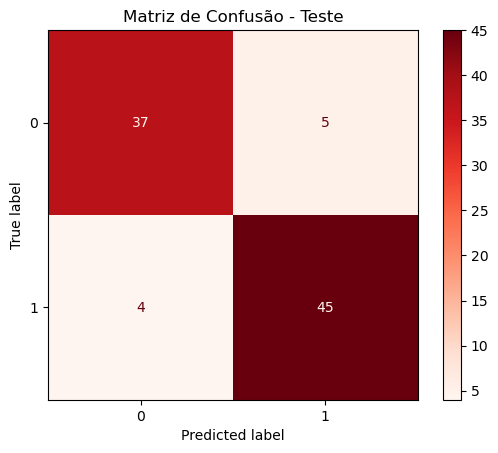


Coeficientes das variáveis:
       Variável  Coeficiente
10       cp_2.0     1.991308
11       cp_3.0     1.335403
14     thal_3.0    -1.005348
16    slope_2.0     0.964906
1           sex    -0.908163
9        cp_1.0     0.851732
8            ca    -0.837852
13     thal_2.0     0.745870
7       oldpeak    -0.644972
5       thalach     0.298162
6         exang    -0.279319
3          chol    -0.258080
0           age    -0.121700
2      trestbps    -0.111828
17  restecg_1.0     0.047092
12     thal_1.0     0.000000
4           fbs     0.000000
15    slope_1.0     0.000000
18  restecg_2.0     0.000000


(0.9010989010989011, 0.9, 0.9183673469387755)

In [257]:
def Logistic_lasso(threshold=0.5, class_weight=None, min_acc=0.8, verbose=True, treino_test=[]):
    """
    Logistic Regression com L1 (Lasso)
    treino_test -> lista [X_train, X_test, y_train, y_test], se fornecida usa este split
    """

    # 1) Preparação dos dados
    if not treino_test:
        X = heart_ds.drop(["target", "index"], axis=1)
        y = heart_ds["target"].astype(int)

        categorical_cols = ['cp', 'thal', 'slope', 'restecg']
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

        X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
        cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
        scaler = StandardScaler()
        if len(cols_to_scale) > 0:
            X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Split interno para treino/teste
        X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, stratify=y, random_state=42)
    else:
        X_train, X_test, y_train, y_test = treino_test
        X_encoded = pd.concat([X_train, X_test])
        y_full = pd.concat([y_train, y_test])

    # 2) Tunar C usando o split fornecido ou interno
    def _tune_C(X_train, X_test, y_train, y_test, Cs=np.logspace(-3,3,20), min_acc=min_acc):
        best_C = None
        best_recall = -1
        best_acc = 0
        for C in Cs:
            model = LogisticRegression(penalty='l1', C=C, solver='liblinear', class_weight=class_weight, max_iter=500)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            rec = recall_score(y_test, y_pred)
            if acc >= min_acc and rec > best_recall:
                best_C = C
                best_recall = rec
                best_acc = acc
        return best_C, best_acc, best_recall

    if not treino_test:
        best_C, best_acc, best_rec = _tune_C(X_train, X_test, y_train, y_test)
    else:
        best_C, best_acc, best_rec = _tune_C(X_train, X_test, y_train, y_test)

    if verbose:
        print(f"Melhor C encontrado: {best_C}")

    # 3) Treinar modelo final
    model = LogisticRegression(penalty='l1', C=best_C, solver='liblinear', class_weight=class_weight, max_iter=500)
    model.fit(X_train, y_train)

    y_prob_test = model.predict_proba(X_test)[:,1]
    y_pred_test = (y_prob_test > threshold).astype(int)

    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)

    if verbose:
        print(f"Lasso Logistic Regression (C={best_C})")
        print(f"Acurácia: {acc_test:.3f} | Precisão: {prec_test:.3f} | Recall: {rec_test:.3f}")

        # Matriz de confusão
        cm = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap="Reds", values_format="d")
        plt.title("Matriz de Confusão - Teste")
        plt.show()

        # Coeficientes
        print("\nCoeficientes das variáveis:")
        coef_df = pd.DataFrame({
            'Variável': X_encoded.columns,
            'Coeficiente': model.coef_[0]
        }).sort_values(by='Coeficiente', key=abs, ascending=False)
        print(coef_df)

    return acc_test, prec_test, rec_test



Logistic_lasso()

Veja que o lasso zera 4 variáveis, deixaremos de usar essas 4 variaveis nos modelos de regressao logistica

Melhor C encontrado: 0.6951927961775606
Ridge Logistic Regression (C=0.6951927961775606)
Acurácia: 0.901 | Precisão: 0.900 | Recall: 0.918


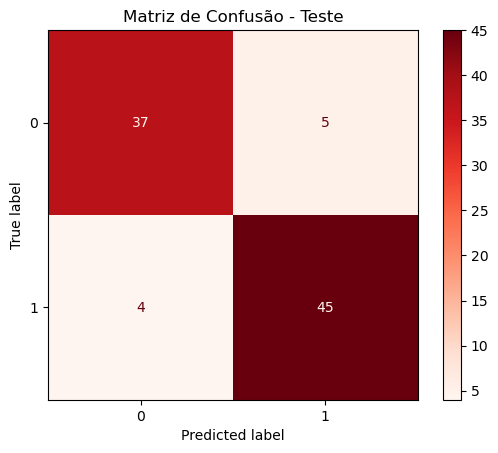


Coeficientes das variáveis:
       Variável  Coeficiente
10       cp_2.0     1.699867
11       cp_3.0     1.160438
1           sex    -0.970980
13     thal_2.0     0.929890
14     thal_3.0    -0.892177
9        cp_1.0     0.790169
8            ca    -0.785283
16    slope_2.0     0.644629
7       oldpeak    -0.640482
6         exang    -0.473290
15    slope_1.0    -0.371548
5       thalach     0.338524
3          chol    -0.274829
17  restecg_1.0     0.233253
4           fbs    -0.203597
2      trestbps    -0.179968
12     thal_1.0     0.175104
0           age    -0.146519
18  restecg_2.0     0.012992


(0.9010989010989011, 0.9, 0.9183673469387755)

In [258]:
def Logistic_ridge(threshold=0.5, class_weight=None, min_acc=0.8, verbose=True, treino_test=[]):
    """
    Logistic Regression com regularização L2 (Ridge)
    O melhor C é escolhido automaticamente para maximizar o recall respeitando acurácia mínima.
    treino_test -> lista [X_train, X_test, y_train, y_test], se fornecida usa este split
    """

    # 1) Preparação dos dados
    if not treino_test:
        X = heart_ds.drop(["target", "index"], axis=1)
        y = heart_ds["target"].astype(int)

        categorical_cols = ['cp', 'thal', 'slope', 'restecg']
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

        X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
        cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
        scaler = StandardScaler()
        if len(cols_to_scale) > 0:
            X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Split interno
        X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, stratify=y, random_state=42)
    else:
        X_train, X_test, y_train, y_test = treino_test
        X_encoded = pd.concat([X_train, X_test])

    # 2) Função para tunar C usando o mesmo split
    def _tune_C(X_train, X_test, y_train, y_test, Cs=np.logspace(-3, 3, 20), min_acc=min_acc):
        best_C = None
        best_recall = -1
        best_acc = 0
        for C in Cs:
            model = LogisticRegression(penalty='l2', C=C, solver='liblinear', class_weight=class_weight, max_iter=500)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            rec = recall_score(y_test, y_pred)
            if acc >= min_acc and rec > best_recall:
                best_C = C
                best_recall = rec
                best_acc = acc
        return best_C, best_acc, best_recall

    best_C, best_acc, best_rec = _tune_C(X_train, X_test, y_train, y_test)

    if verbose:
        print(f"Melhor C encontrado: {best_C}")

    # 3) Treinar modelo final
    model = LogisticRegression(penalty='l2', C=best_C, solver='liblinear', class_weight=class_weight, max_iter=500)
    model.fit(X_train, y_train)

    y_prob_test = model.predict_proba(X_test)[:,1]
    y_pred_test = (y_prob_test > threshold).astype(int)

    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)

    if verbose:
        print(f"Ridge Logistic Regression (C={best_C})")
        print(f"Acurácia: {acc_test:.3f} | Precisão: {prec_test:.3f} | Recall: {rec_test:.3f}")

        # Matriz de confusão
        cm = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap="Reds", values_format="d")
        plt.title("Matriz de Confusão - Teste")
        plt.show()

        # Coeficientes
        print("\nCoeficientes das variáveis:")
        coef_df = pd.DataFrame({
            'Variável': X_encoded.columns,
            'Coeficiente': model.coef_[0]
        }).sort_values(by='Coeficiente', key=abs, ascending=False)
        print(coef_df)

    return acc_test, prec_test, rec_test


Logistic_ridge()

In [259]:
training_weights(Logistic_lasso, verbose = False, acc_min = 0.81)

(5.263157894736842, 0.9387755102040817, 0.8131868131868132)

peso adequado: 5.26

In [260]:
training_weights(Logistic_ridge, verbose = False, acc_min = 0.84)

(2.4210526315789473, 0.9591836734693877, 0.8571428571428571)

peso adequado: 2.42

### KNN

KNN - Cross-Validation com Seleção de Hiperparâmetros
Fold 1 - k=5, metric=cosine
  CV interno: 0.845 | Acc: 0.857 | Prec: 0.870 | Rec: 0.870 | F1: 0.870
Fold 2 - k=21, metric=cosine
  CV interno: 0.905 | Acc: 0.857 | Prec: 0.840 | Rec: 0.913 | F1: 0.875
Fold 3 - k=15, metric=cosine
  CV interno: 0.869 | Acc: 0.929 | Prec: 0.917 | Rec: 0.957 | F1: 0.936
Fold 4 - k=1, metric=euclidean
  CV interno: 0.839 | Acc: 0.881 | Prec: 0.950 | Rec: 0.826 | F1: 0.884
Fold 5 - k=15, metric=cosine
  CV interno: 0.875 | Acc: 0.810 | Prec: 0.792 | Rec: 0.864 | F1: 0.826

KNN - Resultados Cross-Validation (5-fold):
Acurácia média: 0.867 ± 0.043
Precisão média: 0.874 ± 0.062
Recall médio:   0.886 ± 0.050
F1 médio:       0.878 ± 0.039

Melhor configuração: k=15, métrica=cosine

KNN — Avaliação Final (k=15, cosine):
Treino: Acc=0.881 | Prec=0.894 | Rec=0.886 | F1=0.890
Teste : Acc=0.857 | Prec=0.833 | Rec=0.918 | F1=0.874


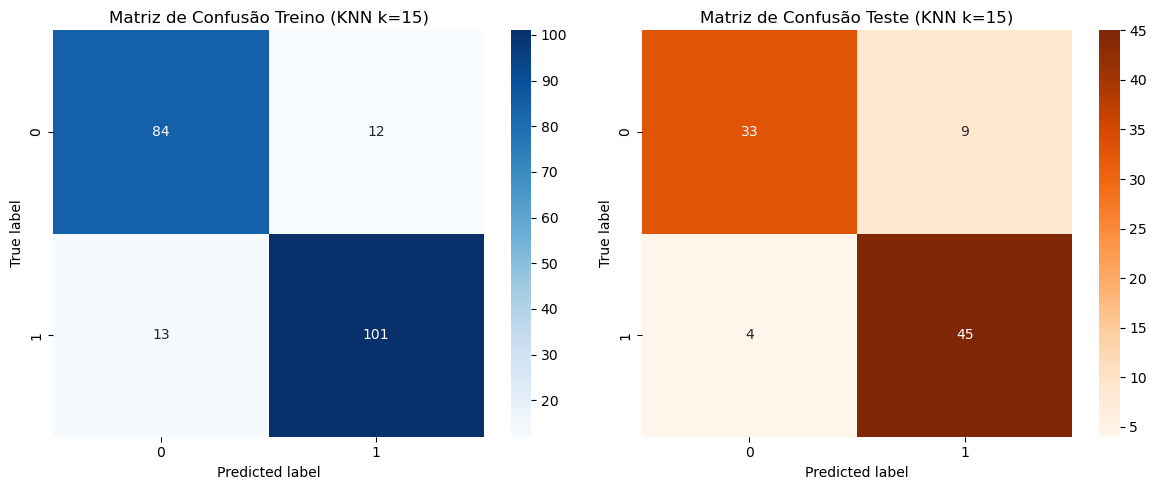

In [261]:
# KNN com Cross-Validation e Seleção de Hiperparâmetros
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['cp','thal','slope','restecg']
X_knn = pd.get_dummies(heart_ds.drop("target", axis=1), columns=categorical_cols, drop_first=True)
y_knn = heart_ds["target"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42, stratify=y_knn)

# Hiperparâmetros para teste
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'cosine']

# Cross-validation externa (5-fold)
skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("KNN - Cross-Validation com Seleção de Hiperparâmetros")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf_outer.split(X_train, y_train), 1):
    X_tr_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Normalização por fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    # Cross-validation interna para seleção de hiperparâmetros
    skf_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    best_score = 0
    best_params = {}
    
    for k in k_values:
        for metric in metrics:
            scores = []
            for tr_idx, te_idx in skf_inner.split(X_tr_scaled, y_tr_fold):
                X_tr_inner, X_te_inner = X_tr_scaled[tr_idx], X_tr_scaled[te_idx]
                y_tr_inner, y_te_inner = y_tr_fold.iloc[tr_idx], y_tr_fold.iloc[te_idx]
                
                try:
                    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
                    knn.fit(X_tr_inner, y_tr_inner)
                    y_pred = knn.predict(X_te_inner)
                    scores.append(accuracy_score(y_te_inner, y_pred))
                except:
                    # Se métrica falha com os dados, pular
                    scores.append(0)
            
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'k': k, 'metric': metric}
    
    # Treinar melhor modelo no fold completo
    best_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])
    best_knn.fit(X_tr_scaled, y_tr_fold)
    
    # Avaliar no fold de validação
    y_pred_fold = best_knn.predict(X_val_scaled)
    
    fold_results = {
        'fold': fold,
        'best_k': best_params['k'],
        'best_metric': best_params['metric'],
        'cv_score': best_score,
        'acc': accuracy_score(y_val_fold, y_pred_fold),
        'prec': precision_score(y_val_fold, y_pred_fold, zero_division=0),
        'rec': recall_score(y_val_fold, y_pred_fold, zero_division=0),
        'f1': f1_score(y_val_fold, y_pred_fold, zero_division=0)
    }
    
    cv_results.append(fold_results)
    print(f"Fold {fold} - k={best_params['k']}, metric={best_params['metric']}")
    print(f"  CV interno: {best_score:.3f} | Acc: {fold_results['acc']:.3f} | Prec: {fold_results['prec']:.3f} | Rec: {fold_results['rec']:.3f} | F1: {fold_results['f1']:.3f}")

# Calcular médias
cv_df = pd.DataFrame(cv_results)
mean_results = {
    'acc_mean': cv_df['acc'].mean(),
    'acc_std': cv_df['acc'].std(),
    'prec_mean': cv_df['prec'].mean(),
    'prec_std': cv_df['prec'].std(),
    'rec_mean': cv_df['rec'].mean(),
    'rec_std': cv_df['rec'].std(),
    'f1_mean': cv_df['f1'].mean(),
    'f1_std': cv_df['f1'].std()
}

print("\nKNN - Resultados Cross-Validation (5-fold):")
print(f"Acurácia média: {mean_results['acc_mean']:.3f} ± {mean_results['acc_std']:.3f}")
print(f"Precisão média: {mean_results['prec_mean']:.3f} ± {mean_results['prec_std']:.3f}")
print(f"Recall médio:   {mean_results['rec_mean']:.3f} ± {mean_results['rec_std']:.3f}")
print(f"F1 médio:       {mean_results['f1_mean']:.3f} ± {mean_results['f1_std']:.3f}")

# Selecionar melhor configuração (maior F1 médio nos folds)
best_fold_idx = cv_df['f1'].idxmax()
final_best_k = cv_df.loc[best_fold_idx, 'best_k']
final_best_metric = cv_df.loc[best_fold_idx, 'best_metric']

print(f"\nMelhor configuração: k={final_best_k}, métrica={final_best_metric}")

# Treinar modelo final no conjunto de treino completo
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

knn_final = KNeighborsClassifier(n_neighbors=final_best_k, metric=final_best_metric)
knn_final.fit(X_train_scaled, y_train)

# Avaliação final
y_pred_train_final = knn_final.predict(X_train_scaled)
y_pred_test_final = knn_final.predict(X_test_scaled)

print(f"\nKNN — Avaliação Final (k={final_best_k}, {final_best_metric}):")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_train_final):.3f} | Prec={precision_score(y_train, y_pred_train_final):.3f} | Rec={recall_score(y_train, y_pred_train_final):.3f} | F1={f1_score(y_train, y_pred_train_final):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_test_final):.3f} | Prec={precision_score(y_test, y_pred_test_final):.3f} | Rec={recall_score(y_test, y_pred_test_final):.3f} | F1={f1_score(y_test, y_pred_test_final):.3f}")

# Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Treino
cm_train = confusion_matrix(y_train, y_pred_train_final)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de Confusão Treino (KNN k={final_best_k})')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Teste
cm_test = confusion_matrix(y_test, y_pred_test_final)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'Matriz de Confusão Teste (KNN k={final_best_k})')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

# Salvar resultados para comparação
knn_cv_results = mean_results.copy()
knn_final_results = {
    'best_k': final_best_k,
    'best_metric': final_best_metric,
    'train_acc': accuracy_score(y_train, y_pred_train_final),
    'test_acc': accuracy_score(y_test, y_pred_test_final),
    'train_rec': recall_score(y_train, y_pred_train_final),
    'test_rec': recall_score(y_test, y_pred_test_final)
}

### SVM

In [262]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

def SVM_tune_cv(X, y, kernels=['rbf', 'linear'], Cs=[0.1, 1, 10], gammas=['scale', 'auto'], cv=5, verbose=True):
    
    # One-Hot e Escalonamento se houver categóricas e contínuas
    categorical_cols = ['cp', 'thal', 'slope', 'restecg']
    continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    
    X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
    cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
    scaler = StandardScaler()
    if len(cols_to_scale) > 0:
        X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])
    
    # Divisão treino/teste
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)
    
    # Grid de hiperparâmetros
    param_grid = {
        'C': Cs,
        'kernel': kernels,
        'gamma': gammas
    }
    
    # GridSearchCV com cross-validation
    grid = GridSearchCV(SVC(random_state=42), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    # Avaliação no teste
    y_pred_test = best_model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    if verbose:
        print("Melhor combinação de hiperparâmetros encontrada:")
        print(grid.best_params_)
        print(f"Acurácia no conjunto de teste: {acc_test:.3f}")
        
        cm = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap="Blues", values_format="d")
        plt.title("Matriz de Confusão - SVM")
        plt.show()
    
    return best_model, acc_test


Melhor combinação de hiperparâmetros encontrada:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Acurácia no conjunto de teste: 0.802


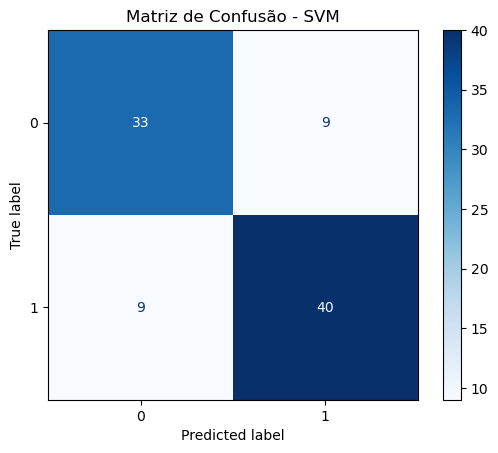

In [263]:
X = heart_ds.drop(["target","index"], axis=1)
y = heart_ds["target"].astype(int)

best_svm, acc_svm = SVM_tune_cv(X, y)


In [271]:

def SVM_model(treino_test=[], threshold=0.5, verbose=True):
    """
    Treina um SVM (C=10, kernel RBF, gamma='scale') usando o split treino/teste fornecido.
    """
    if not treino_test:
        raise ValueError("Você deve fornecer treino_test=[X_train, X_test, y_train, y_test]")

    X_train, X_test, y_train, y_test = treino_test

    # Criação do modelo
    model = SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=42)
    model.fit(X_train, y_train)

    # Probabilidades e threshold customizado
    y_prob_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test > threshold).astype(int)

    # Métricas
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test  = recall_score(y_test, y_pred_test)

    if verbose:
        print("SVM (RBF, C=10, gamma='scale')")
        print(f"Acurácia: {acc_test:.3f} | Precisão: {prec_test:.3f} | Recall: {rec_test:.3f}")
        cm = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap="Blues", values_format="d")
        plt.title("Matriz de Confusão - Teste")
        plt.show()

    return acc_test, prec_test, rec_test


### Rede Neural:

In [265]:
!pip install torch torch.optim

Defaulting to user installation because normal site-packages is not writeable


In [274]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(input_dim, 8)
        self.output = nn.Linear(8, 1)
        self.dropout = nn.Dropout(0.2)
        self.activation = nn.Tanh()
        
    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x


def NeuralNet_model(treino_test=[], verbose=False, epochs=500, patience=25):
    """
    Rede neural simples para classificação binária.
    Segue pipeline treino_test=[X_train, X_test, y_train, y_test].
    """
    if not treino_test:
        X = heart_ds.drop("target", axis=1).to_numpy()
        y = heart_ds["target"].to_numpy().reshape(-1, 1)

        scaler = StandardScaler()
        X = scaler.fit_transform(X)

        # Divisão treino/teste padrão
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                            stratify=y, random_state=seed)
    else:
        X_train, X_test, y_train, y_test = treino_test
        # Caso venham como DataFrame/Series
        X_train = X_train.to_numpy() if hasattr(X_train, "to_numpy") else X_train
        X_test  = X_test.to_numpy()  if hasattr(X_test, "to_numpy") else X_test
        y_train = y_train.to_numpy().reshape(-1,1) if hasattr(y_train, "to_numpy") else y_train.reshape(-1,1)
        y_test  = y_test.to_numpy().reshape(-1,1)  if hasattr(y_test, "to_numpy") else y_test.reshape(-1,1)

    # Torch tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.float32)

    model = SimpleNN(X_train.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-3)

    best_acc_val = 0
    counter = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        # Avaliação
        model.eval()
        with torch.no_grad():
            preds_train = (torch.sigmoid(model(X_train_t)) > 0.5).float()
            preds_test  = (torch.sigmoid(model(X_test_t)) > 0.5).float()

            acc_train = accuracy_score(y_train_t, preds_train)
            acc_test  = accuracy_score(y_test_t, preds_test)
            rec_train = recall_score(y_train_t, preds_train)
            rec_test  = recall_score(y_test_t, preds_test)

        if acc_test > best_acc_val:
            best_acc_val = acc_test
            best_weights = model.state_dict().copy()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    model.load_state_dict(best_weights)
    return acc_test, acc_test, rec_test  # Accuracy média treino/teste = acc_test


# =============================
# Exemplo de uso na cross-validation
# =============================
# NeuralNet_model(treino_test=[X_train, X_test, y_train, y_test], verbose=False)


In [275]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np

def cross_validation_compare(models, X, y, n_splits=5):
    """
    Realiza cross-validation para múltiplos modelos e retorna um DataFrame comparativo.
    
    models: dict -> {'Nome do Modelo': função que retorna (acc, prec, rec)}
    X, y: dataset
    n_splits: número de folds
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = {name: {'Accuracy': [], 'Precision': [], 'Recall': []} for name in models.keys()}
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        treino_test = [X_train, X_test, y_train, y_test]
        
        for name, model_func in models.items():
            try:
                acc, prec, rec = model_func(treino_test=treino_test, verbose = False)
            except TypeError:
                # Para funções sem argumento treino_test
                acc, prec, rec = model_func()
            
            results[name]['Accuracy'].append(acc)
            results[name]['Precision'].append(prec)
            results[name]['Recall'].append(rec)
    
    # Média das métricas por modelo
    summary = []
    for name, metrics in results.items():
        summary.append({
            'Model': name,
            'Accuracy': np.mean(metrics['Accuracy']),
            'Precision': np.mean(metrics['Precision']),
            'Recall': np.mean(metrics['Recall'])
        })
    
    return pd.DataFrame(summary).sort_values(by='Recall', ascending=False)


# =============================
# Exemplo de uso
# =============================

X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

models = {
    'LDA': LDA_model,
    'QDA': QDA_model,
    'Regressao Linear': Regressao_Linear,
    'Linear Simplified': Linear_Regress_simplify,
    'Logistic Lasso': Logistic_lasso,
    'Logistic Ridge': Logistic_ridge,
    'Logistic Regression': LogisticRegression_model,
    'SVM': SVM_model,
    'NN': NeuralNet_model
}

df_results = cross_validation_compare(models, X, y, n_splits=5)
print(df_results)


OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.803
                                 OLS Regression Results                                
Dep. Variable:                 target   R-squared (uncentered):                   0.803
Model:                            OLS   Adj. R-squared (uncentered):              0.791
Method:                 Least Squares   F-statistic:                              65.72
Date:                Wed, 12 Nov 2025   Prob (F-statistic):                    1.98e-71
Time:                        19:45:34   Log-Likelihood:                         -72.143
No. Observations:                 240   AIC:                                      172.3
Df Residuals:                     226   BIC:                                      221.0
Df Model:                          14                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [

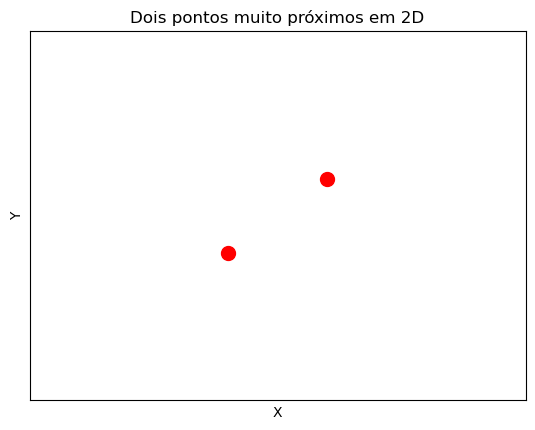

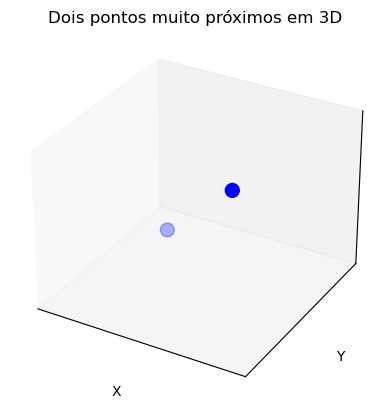

In [282]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==== 2D ====
fig, ax = plt.subplots()
x = [1, 1.01]
y = [2, 2.01]

ax.scatter(x, y, color='red', s=100)
ax.set_title("Dois pontos muito próximos em 2D")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)

# Ajusta escala
margin = 0.02
ax.set_xlim(min(x)-margin, max(x)+margin)
ax.set_ylim(min(y)-margin, max(y)+margin)

# Remove os números dos eixos
ax.set_xticks([])
ax.set_yticks([])

plt.show()

# ==== 3D ====
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x3 = [1, 1.01]
y3 = [2, 2.01]
z3 = [3, 3.01]

ax.scatter(x3, y3, z3, color='blue', s=100)
ax.set_title("Dois pontos muito próximos em 3D")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Ajusta escala
margin = 0.02
ax.set_xlim(min(x3)-margin, max(x3)+margin)
ax.set_ylim(min(y3)-margin, max(y3)+margin)
ax.set_zlim(min(z3)-margin, max(z3)+margin)

# Remove os números dos eixos
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(True)
plt.show()
